# 📊 Small-Cap Mutual Fund Portfolio Analysis
### Top 10 Small-Cap Funds by AUM — Nov 2025 to Apr 2026
**Objective:** Identify common holdings and track whether fund managers are consistently accumulating or reducing stocks.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

FILE = 'Portfolio11.xlsx'

FUNDS = [
    'HSBC', 'Nippon India', 'HDFC', 'SBI', 'Quant',
    'AXIS', 'Kotak', 'Franklin', 'DSP', 'Bandhan'
]

MONTHS_ORDER = ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

NON_STOCK = [
    'AUM',
    'Cash and Other Receivables',
    'NIFTY',
    'MIDCAPNIFTY 30/12/2025'
]

raw_data = {}
aum_data = {}

def convert_month_col(col):
    """
    Converts Excel columns like:
    Apr-26 -> 2026-04
    Mar-26 -> 2026-03
    Dec-25 -> 2025-12
    """
    if col == 'Security Name':
        return col
    
    try:
        return pd.to_datetime(str(col), format='%b-%y').strftime('%Y-%m')
    except:
        try:
            return pd.to_datetime(col).strftime('%Y-%m')
        except:
            return str(col).strip()


for fund in FUNDS:
    df = pd.read_excel(FILE, sheet_name=fund, na_values=['-', '–', ''])
    
    # Clean column names
    df.columns = [convert_month_col(c) for c in df.columns]
    
    # Clean security names
    df['Security Name'] = df['Security Name'].astype(str).str.strip()
    
    # Extract AUM row
    aum_row = df[df['Security Name'].str.upper() == 'AUM']
    if not aum_row.empty:
        aum_data[fund] = aum_row.iloc[0, 1:].to_dict()
    
    # Remove non-stock rows
    df = df[~df['Security Name'].isin(NON_STOCK)].copy()
    df = df.dropna(subset=['Security Name'])
    
    # Remove blank / nan names
    df = df[~df['Security Name'].isin(['nan', 'None', ''])]
    
    # Set index
    df = df.set_index('Security Name')
    
    # Keep only required months
    month_cols = [m for m in MONTHS_ORDER if m in df.columns]
    df = df[month_cols]
    
    # Convert values to numeric
    df = df.apply(pd.to_numeric, errors='coerce')
    
    raw_data[fund] = df

print('✅ Data loaded for funds:', list(raw_data.keys()))

print('\n📅 Months available per fund:')
for f, d in raw_data.items():
    print(f'  {f}: {list(d.columns)}')

print('\n✅ Sample check:')
for f, d in raw_data.items():
    print(f'\n{f}')
    print(d.head())

✅ Data loaded for funds: ['HSBC', 'Nippon India', 'HDFC', 'SBI', 'Quant', 'AXIS', 'Kotak', 'Franklin', 'DSP', 'Bandhan']

📅 Months available per fund:
  HSBC: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Nippon India: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  HDFC: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  SBI: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Quant: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  AXIS: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Kotak: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Franklin: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  DSP: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Bandhan: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

✅ Sample check:

HSBC
                                              2025-11     202

---
## Analysis 1 — Common Holdings Across Funds
**Question:** Which stocks are held by how many small-cap funds at the same time?

📋 Holdings Distribution Table — Apr 2026


,# Funds Holding,Stock Count,Stocks
0,7,3,"Krishna Institute of Medical Sciences Limited, Kalpataru Projects International Limited, Aster DM Healthcare Limited"
1,6,4,"PNB Housing Finance Limited, Kirloskar Oil Engines Limited, City Union Bank Limited, Apar Industries Limited"
2,5,20,"Rolex Rings Limited, Eris Lifesciences Limited, KFin Technologies Limited, Navin Fluorine International Limited, RBL..."
3,4,27,"Vijaya Diagnostic Centre Limited, Lemon Tree Hotels Limited, Ujjivan Small Finance Bank Limited, Safari Industries I..."
4,3,71,"Amber Enterprises India Limited, Computer Age Management Services Limited, Go Fashion India Limited, RHI Magnesita I..."
5,2,179,"Triveni Engineering & Industries Limited, LT Foods Limited, Welspun Living Limited, Motilal Oswal Financial Services..."
6,1,345,"Citius Transnet Investment Trust, GE Vernova T&D India Limited, BSE Limited, Filatex India Limited, Innova Captab Li..."


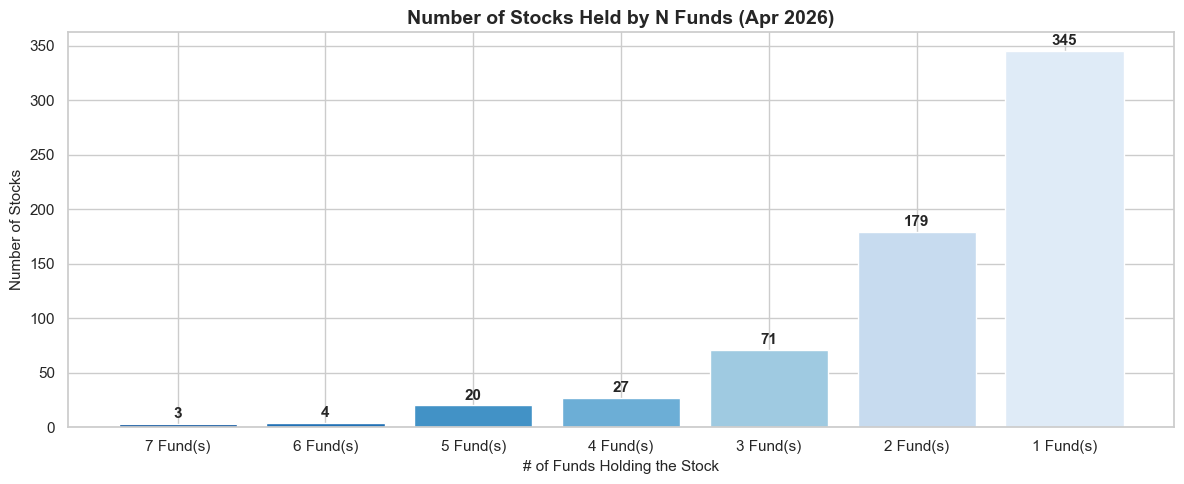

In [74]:
# For each stock, count how many funds hold it in Apr-26 (latest month)
LATEST = '2026-04'

stock_fund_count = {}
for fund, df in raw_data.items():
    if LATEST in df.columns:
        held = df[LATEST].dropna()
        held = held[held > 0]
        for stock in held.index:
            stock_fund_count[stock] = stock_fund_count.get(stock, 0) + 1

count_series = pd.Series(stock_fund_count).sort_values(ascending=False)

# Build table: rows = stocks, col = # of funds (1 to 10)
max_funds = 10
common_table_rows = []
for n_funds in range(max_funds, 0, -1):
    stocks_at_n = count_series[count_series == n_funds].index.tolist()
    common_table_rows.append({'# Funds Holding': n_funds, 'Stock Count': len(stocks_at_n), 'Stocks': ', '.join(stocks_at_n)})

common_table = pd.DataFrame(common_table_rows)
common_table = common_table[common_table['Stock Count'] > 0].reset_index(drop=True)

print('📋 Holdings Distribution Table — Apr 2026')
print('=' * 80)
pd.set_option('display.max_colwidth', 120)
display(common_table)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(common_table['# Funds Holding'].astype(str) + ' Fund(s)', common_table['Stock Count'],
              color=sns.color_palette('Blues_r', len(common_table)))
ax.bar_label(bars, padding=2, fontsize=11, fontweight='bold')
ax.set_title('Number of Stocks Held by N Funds (Apr 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('# of Funds Holding the Stock', fontsize=11)
ax.set_ylabel('Number of Stocks', fontsize=11)
plt.tight_layout()
plt.show()

In [94]:
# Top 20 stocks by number of funds holding them in Apr-26

top20_common_stocks = (
    count_series
    .reset_index()
    .rename(columns={"index": "Stock", 0: "Number of Funds Holding"})
    .sort_values(["Number of Funds Holding", "Stock"], ascending=[False, True])
    .head(20)
    .reset_index(drop=True)
)

print("🏆 Top 20 Stocks by Number of Funds Holding — Apr 2026")
display(top20_common_stocks)

🏆 Top 20 Stocks by Number of Funds Holding — Apr 2026


,Stock,Number of Funds Holding
0,Aster DM Healthcare Limited,7
1,Kalpataru Projects International Limited,7
2,Krishna Institute of Medical Sciences Limited,7
3,Apar Industries Limited,6
4,City Union Bank Limited,6
5,Kirloskar Oil Engines Limited,6
6,PNB Housing Finance Limited,6
7,Angel One Limited,5
8,Balrampur Chini Mills Limited,5
9,Brigade Enterprises Limited,5


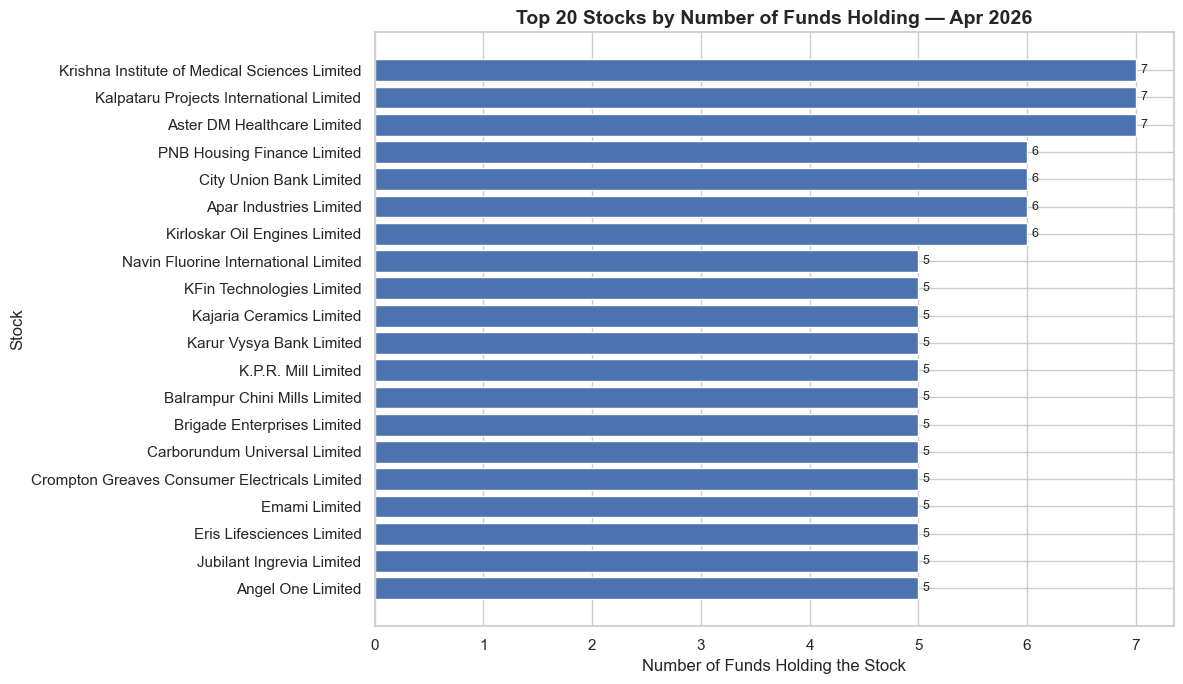

In [95]:
# Graph — Top 20 common holdings

plot_df = top20_common_stocks.sort_values(
    "Number of Funds Holding",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_df["Stock"],
    plot_df["Number of Funds Holding"]
)

ax.bar_label(
    bars,
    labels=[f"{v:.0f}" for v in plot_df["Number of Funds Holding"]],
    padding=3,
    fontsize=9
)

ax.set_title(
    "Top 20 Stocks by Number of Funds Holding — Apr 2026",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Number of Funds Holding the Stock")
ax.set_ylabel("Stock")

plt.subplots_adjust(left=0.38, right=0.95)
plt.tight_layout()
plt.show()

---
## Analysis 2 — Top 10 Common Holdings (Apr-26 to Nov-25)
**Question:** Which stocks appear repeatedly in the top 10 holdings across funds?

In [97]:
# Count holding appearances across all funds and all months
# Meaning: stock has positive AUM in a fund-month

holding_appearances = {}

for fund, df in raw_data.items():
    
    df = df.copy()
    df = df.replace("-", np.nan)
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Combine duplicate stock names if any
    df = df.groupby(df.index).sum(numeric_only=True)
    
    for month in MONTHS_ORDER:
        if month in df.columns:
            
            held = df[month].dropna()
            held = held[held > 0]
            
            for stock in held.index:
                holding_appearances[stock] = holding_appearances.get(stock, 0) + 1

holding_series = pd.Series(holding_appearances).sort_values(ascending=False)

holding_df = pd.DataFrame({
    "Stock": holding_series.index,
    "Holding Appearances (All Funds × All Months)": holding_series.values
})

holding_df.index = range(1, len(holding_df) + 1)

print("🏆 Top 20 Stocks by Holding Appearances")
print("Maximum possible = 10 funds × 6 months = 60")
display(holding_df.head(20))

🏆 Top 20 Stocks by Holding Appearances
Maximum possible = 10 funds × 6 months = 60


,Stock,Holding Appearances (All Funds × All Months)
1,Aster DM Healthcare Limited,42
2,Kalpataru Projects International Limited,38
3,Krishna Institute of Medical Sciences Limited,38
4,City Union Bank Limited,36
5,Apar Industries Limited,35
6,Kirloskar Oil Engines Limited,35
7,Kajaria Ceramics Limited,34
8,RBL Bank Limited,33
9,PNB Housing Finance Limited,33
10,Brigade Enterprises Limited,31


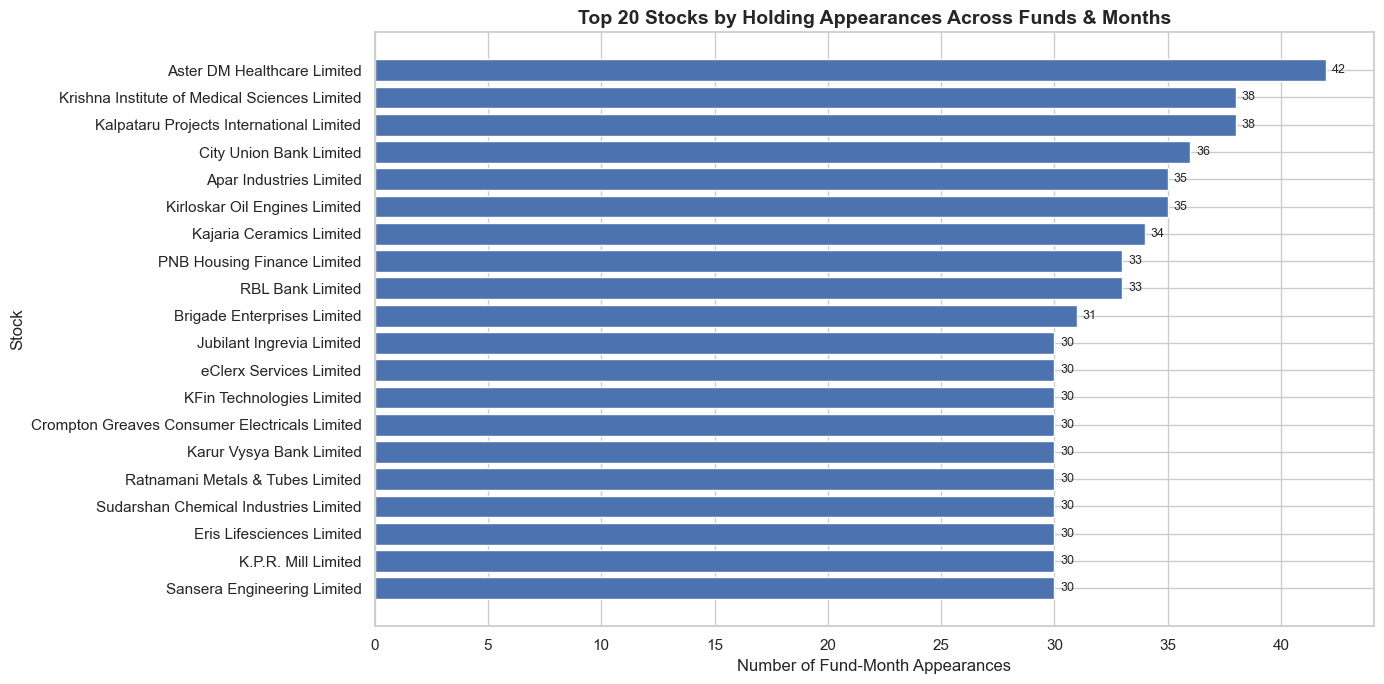

In [98]:
# Chart — Top 20 holding appearances

top20_holding_series = holding_series.head(20)

fig, ax = plt.subplots(figsize=(14, 7))

plot_series = top20_holding_series.sort_values(ascending=True)

bars = ax.barh(
    plot_series.index,
    plot_series.values
)

ax.bar_label(
    bars,
    labels=[f"{v:.0f}" for v in plot_series.values],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 20 Stocks by Holding Appearances Across Funds & Months",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Number of Fund-Month Appearances")
ax.set_ylabel("Stock")

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

---
## Analysis 3 — Net Buy / Net Sell by Fund
**Question:** Which stocks did each fund increase or reduce over Nov-25 to Apr-26?

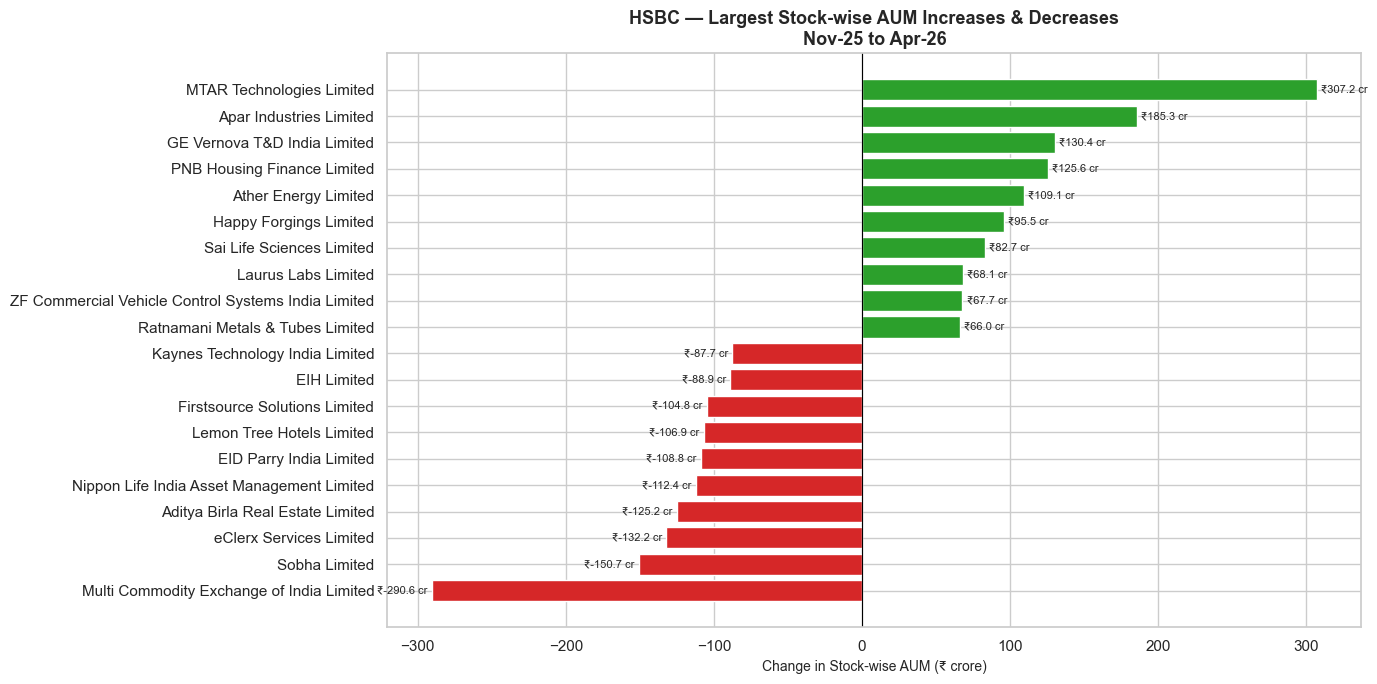

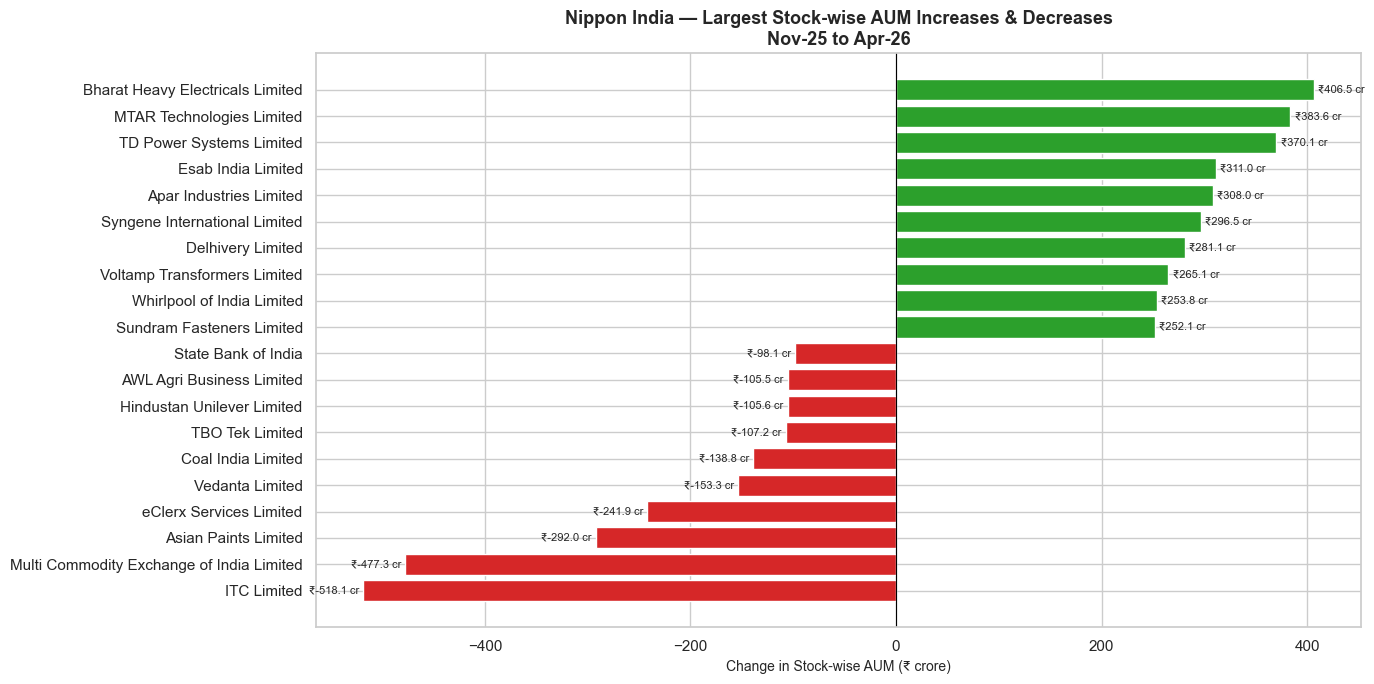

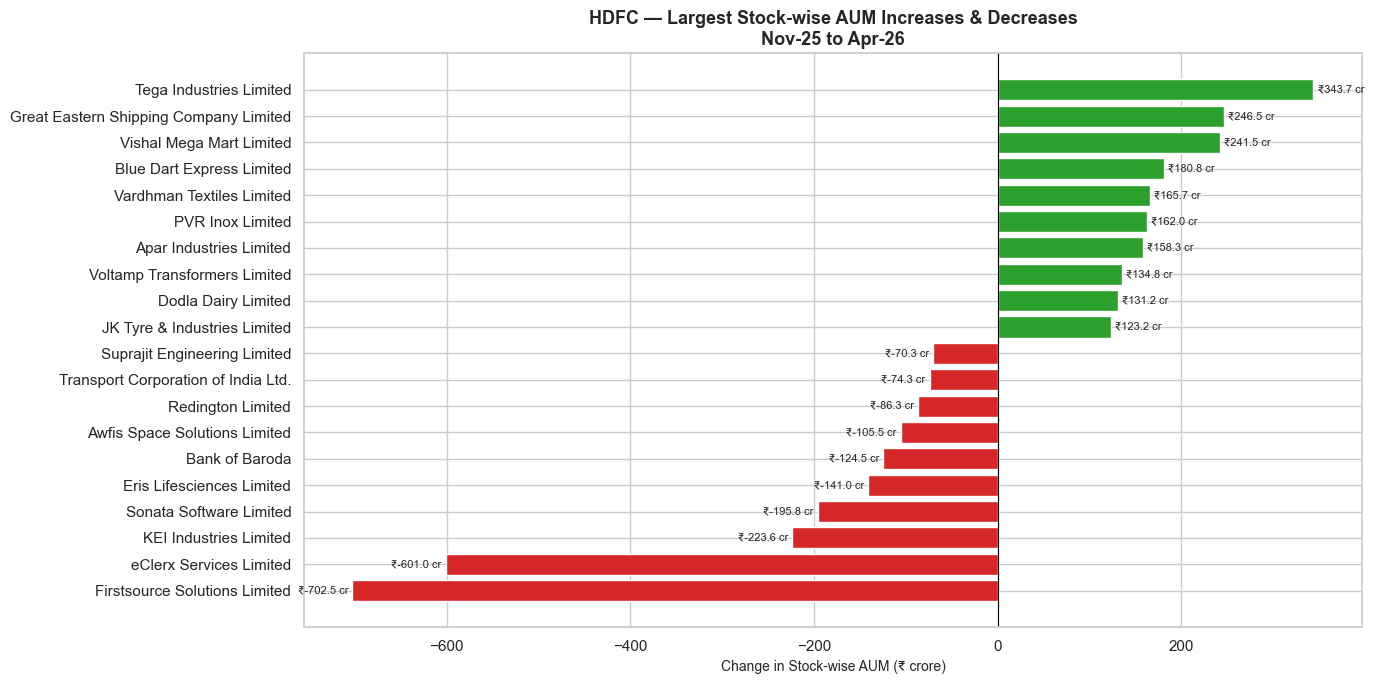

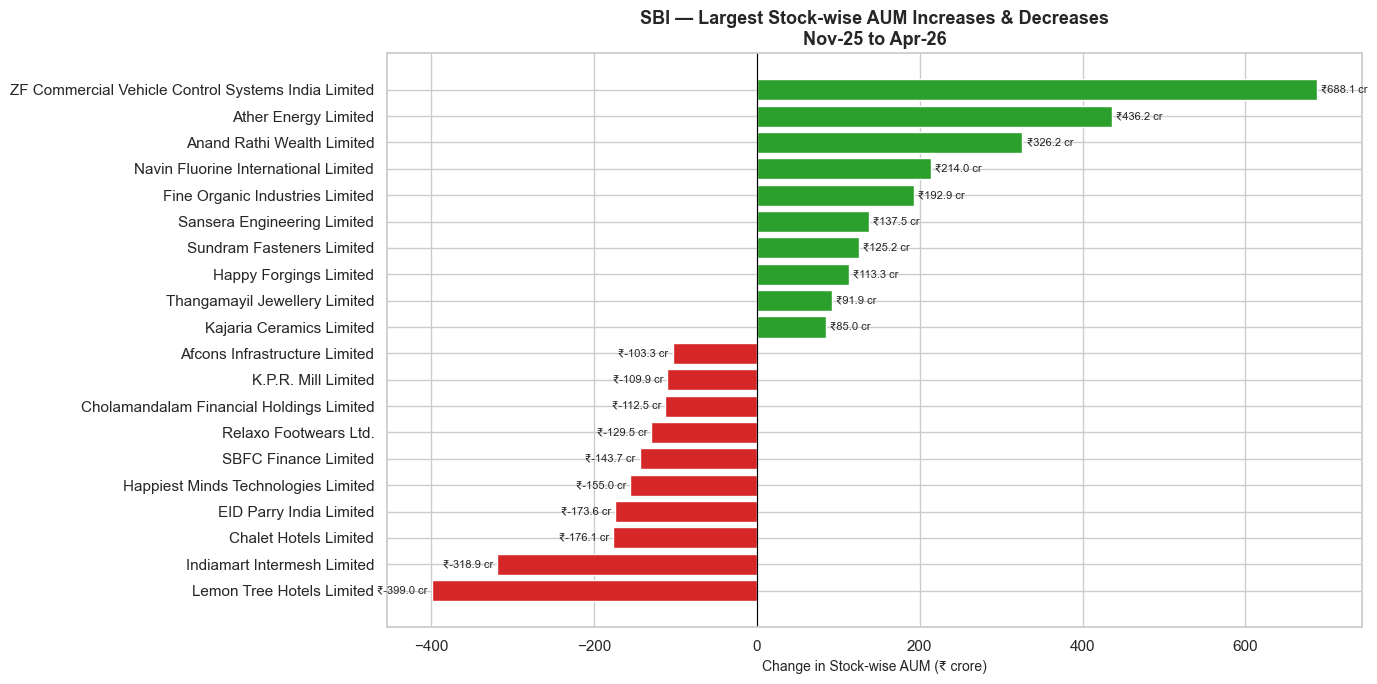

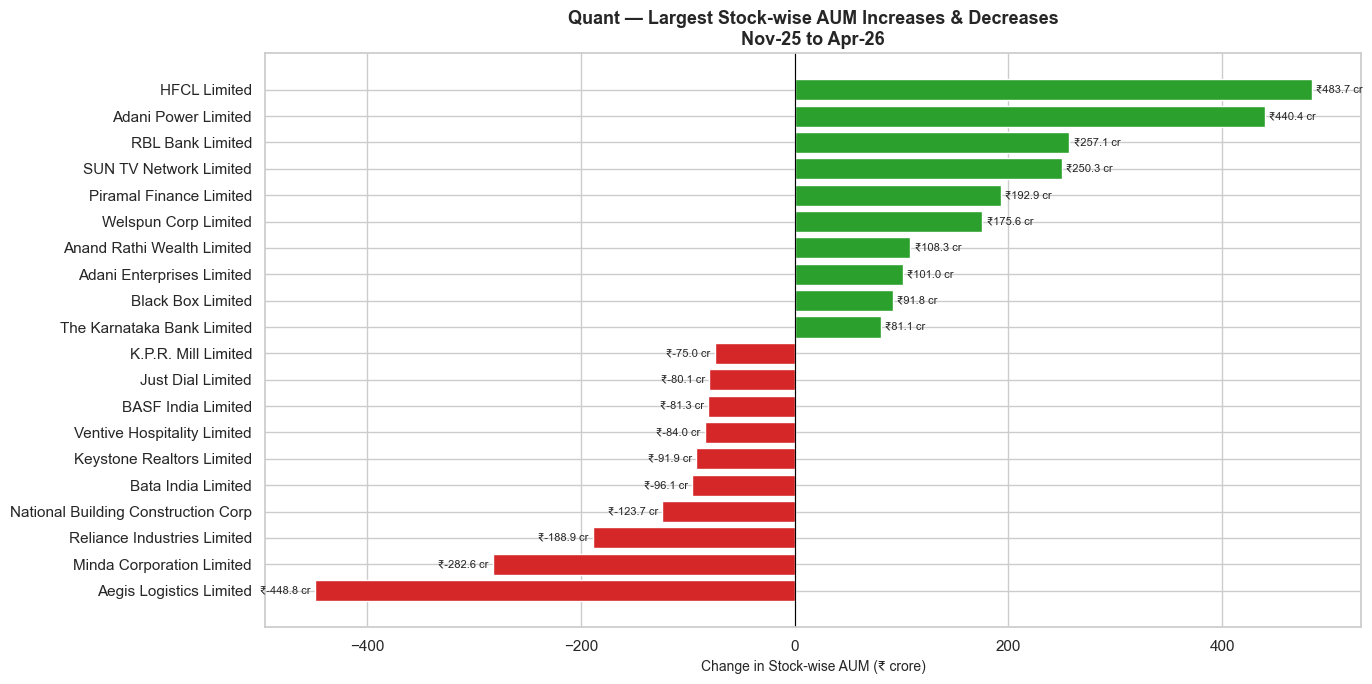

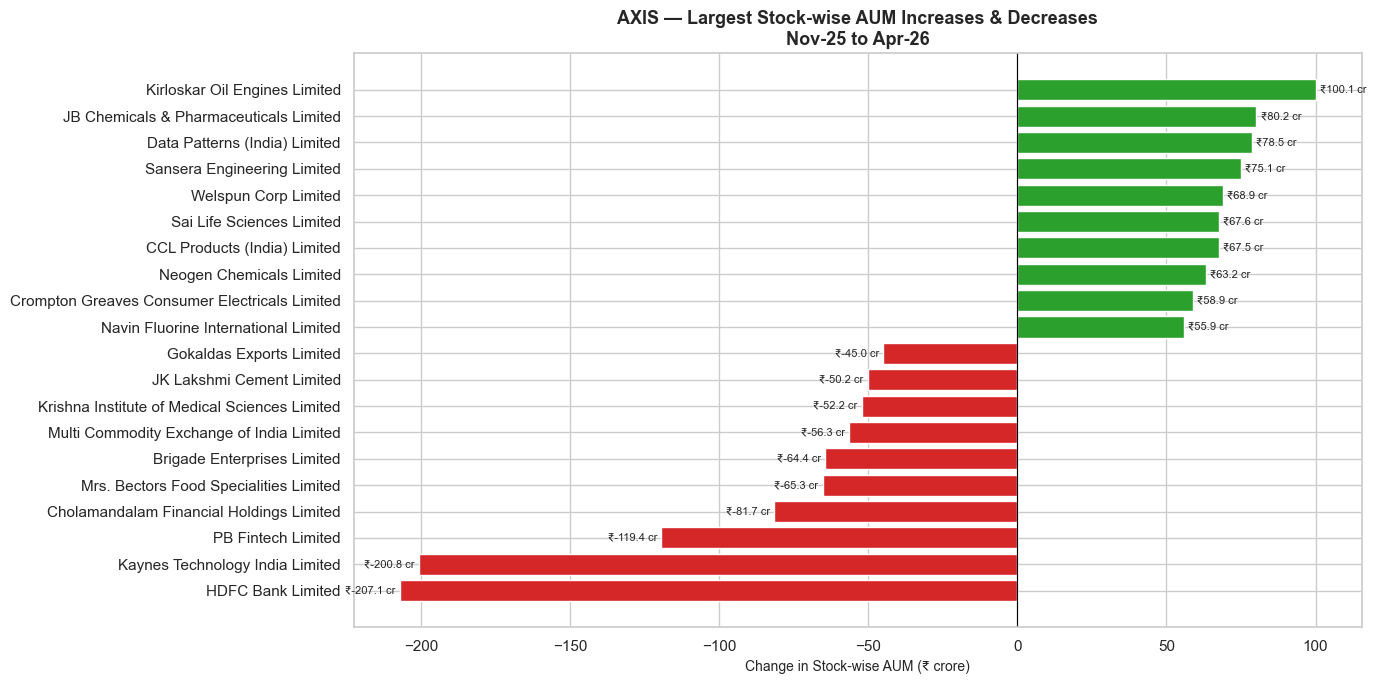

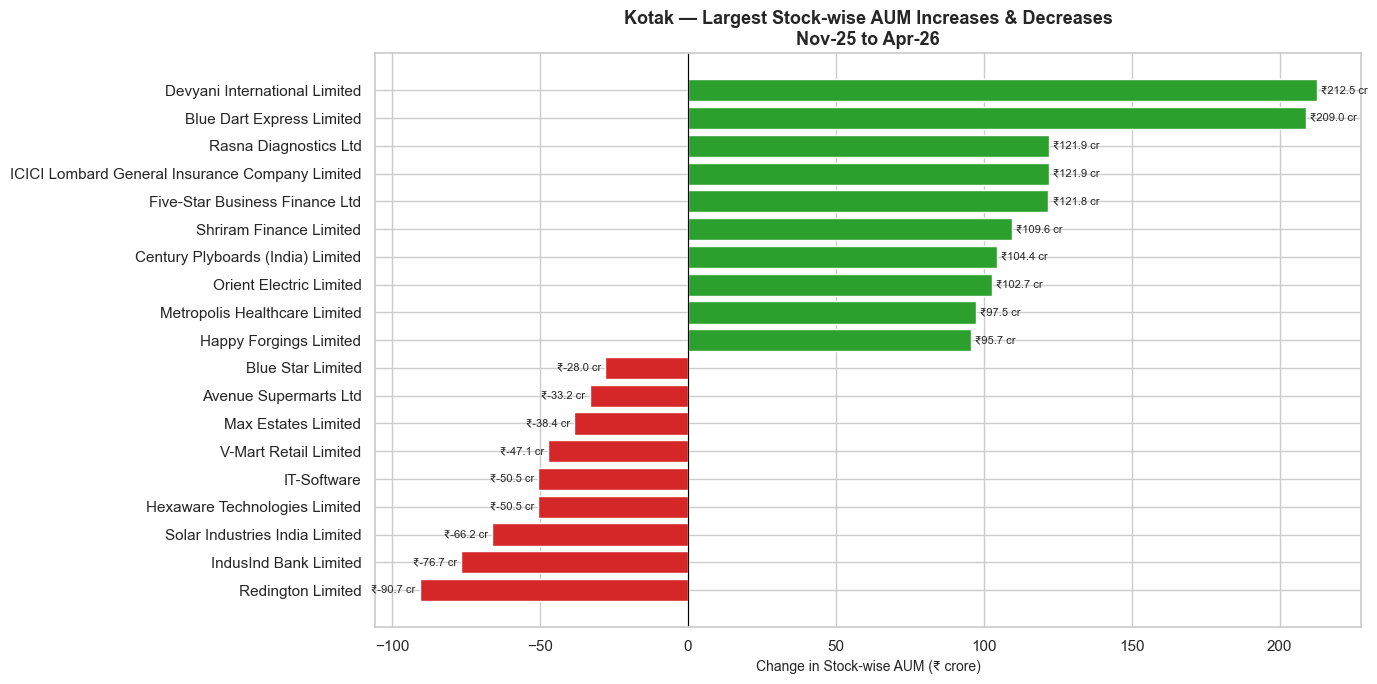

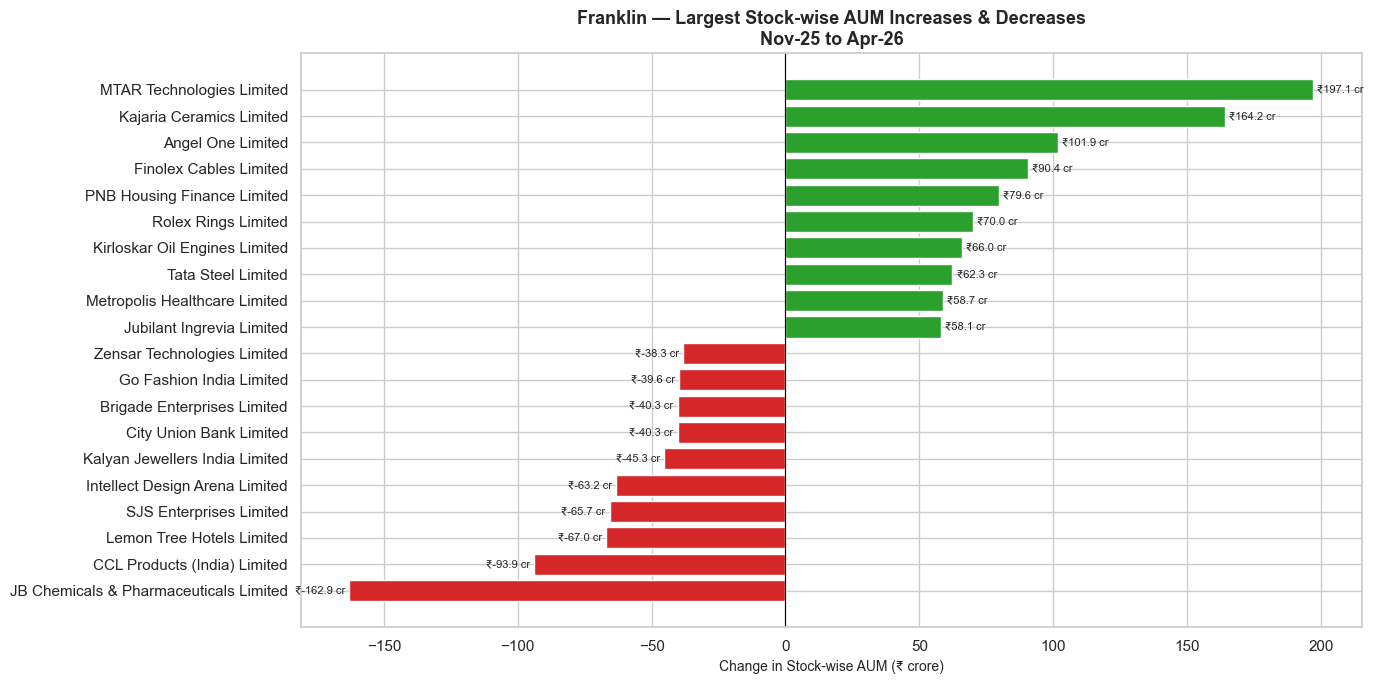

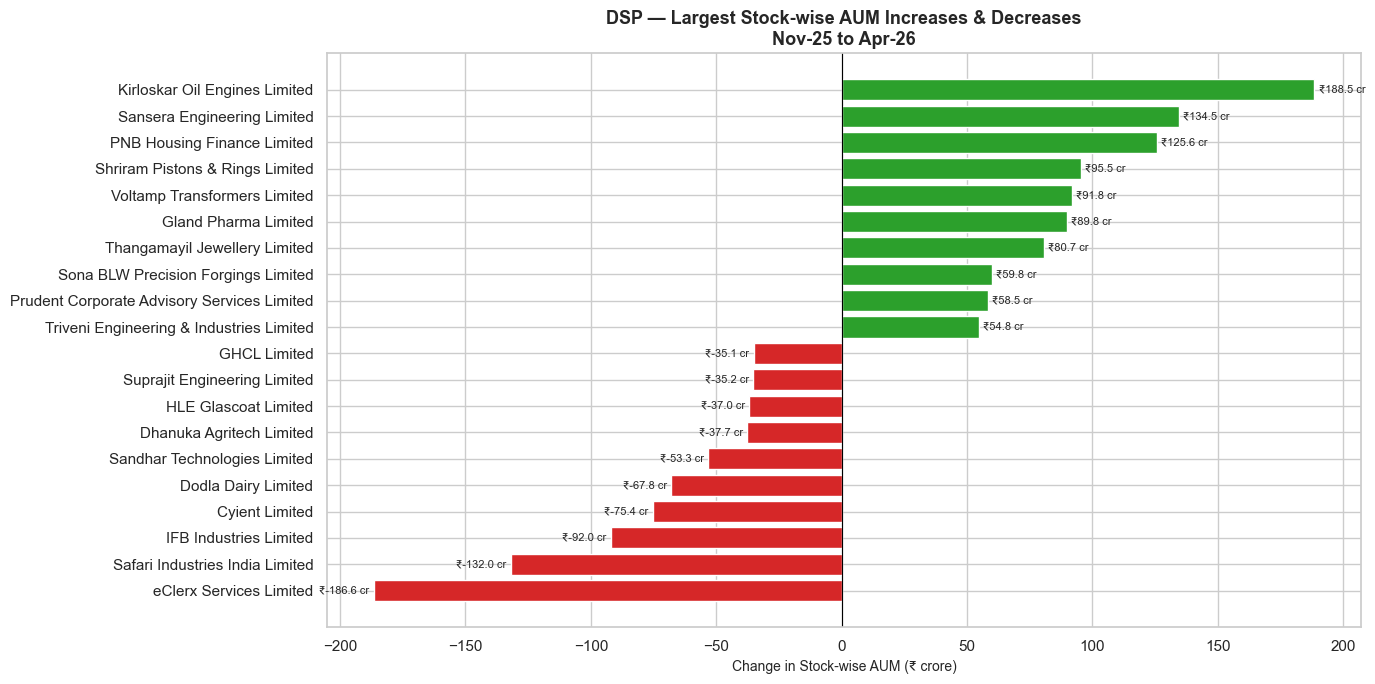

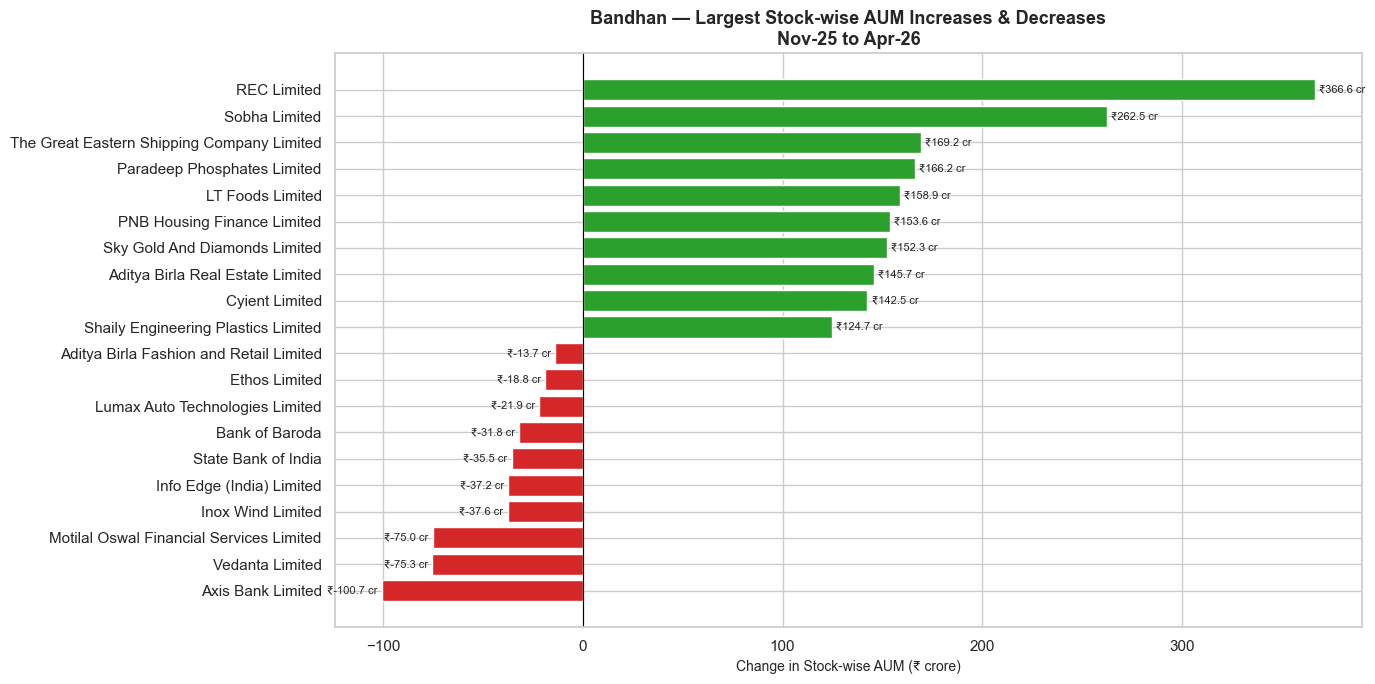

In [99]:
START_MONTH = '2025-11'
END_MONTH = '2026-04'

for fund, df in raw_data.items():
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        print(f'⚠️ Skipping {fund} — missing start or end month')
        continue
    
    # Since values are stock-wise AUM in ₹ crore
    change = df[END_MONTH] - df[START_MONTH]
    change = change.dropna()
    
    if change.empty:
        print(f'⚠️ Skipping {fund} — no valid stock-level AUM change data')
        continue
    
    # Top 10 increase and decrease in stock-wise AUM
    buys = change.nlargest(10)
    sells = change.nsmallest(10)
    
    combined = pd.concat([buys, sells])
    combined = combined[~combined.index.duplicated(keep='first')]
    combined = combined.sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in combined.values]
    
    bars = ax.barh(combined.index, combined.values, color=colors)
    
    ax.axvline(0, color='black', linewidth=0.8)
    
    ax.bar_label(
        bars,
        labels=[f'₹{v:,.1f} cr' for v in combined.values],
        padding=3,
        fontsize=8
    )
    
    ax.set_title(
        f'{fund} — Largest Stock-wise AUM Increases & Decreases\nNov-25 to Apr-26',
        fontsize=13,
        fontweight='bold'
    )
    
    ax.set_xlabel('Change in Stock-wise AUM (₹ crore)', fontsize=10)
    
    plt.subplots_adjust(left=0.35, right=0.95)
    plt.tight_layout()
    plt.show()

---
## Analysis 4 — Buy-Month Count
**Question:** Out of 5 month-to-month changes, how many months did AUM increase for each stock?

### Stock-wise AUM change = fund buying/selling + stock price movement ###
### AUM Increase Months ≠ Buy Months ###
### AUM Decrease Months ≠ Sell Months ###

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

aum_month_data = []

for fund, df in raw_data.items():

    df = df.replace("-", np.nan).copy()

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # If same stock appears more than once, combine stock-wise AUM
    df = df.groupby(df.index).sum(numeric_only=True)

    months = [m for m in MONTHS_ORDER if m in df.columns]

    if len(months) < 2:
        print(f"⚠️ Skipping {fund} — less than 2 months available")
        continue

    for stock in df.index:
        series = df.loc[stock, months]
        series = pd.to_numeric(series, errors="coerce")
        series = series.dropna()

        if len(series) < 2:
            continue

        month_changes = series.diff().dropna()

        increase_months = int((month_changes > 0).sum())
        decrease_months = int((month_changes < 0).sum())
        no_change_months = int((month_changes == 0).sum())

        start_aum = series.iloc[0]
        end_aum = series.iloc[-1]
        net_change = end_aum - start_aum

        aum_month_data.append({
            "Fund": fund,
            "Stock": stock,
            "AUM Increase Months": increase_months,
            "AUM Decrease Months": decrease_months,
            "No Change Months": no_change_months,
            "Total Periods": len(month_changes),
            "Net AUM Change (₹ Cr)": round(net_change, 2),
            "Start AUM (₹ Cr)": round(start_aum, 2),
            "End AUM (₹ Cr)": round(end_aum, 2)
        })

aum_month_df = pd.DataFrame(aum_month_data)

aum_agg = aum_month_df.groupby("Stock").agg(
    Funds_Tracked=("Fund", "count"),
    Total_AUM_Increase_Months=("AUM Increase Months", "sum"),
    Total_AUM_Decrease_Months=("AUM Decrease Months", "sum"),
    Total_No_Change_Months=("No Change Months", "sum"),
    Total_Periods=("Total Periods", "sum"),
    Total_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "sum"),
    Avg_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "mean")
).round(2).reset_index()

# Stocks tracked by at least 5 funds
aum_agg = aum_agg[aum_agg["Funds_Tracked"] >= 5]

# Share of months where AUM increased/decreased
aum_agg["AUM_Increase_Ratio"] = (
    aum_agg["Total_AUM_Increase_Months"] / aum_agg["Total_Periods"]
).round(2)

aum_agg["AUM_Decrease_Ratio"] = (
    aum_agg["Total_AUM_Decrease_Months"] / aum_agg["Total_Periods"]
).round(2)

aum_agg = aum_agg.sort_values(
    ["Total_AUM_Increase_Months", "Total_Net_AUM_Change_Cr"],
    ascending=False
)

print("📈 Total AUM Increase-Month Count — Stocks held by ≥5 Funds")
display(aum_agg.head(27).reset_index(drop=True))

📈 Total AUM Increase-Month Count — Stocks held by ≥5 Funds


,Stock,Funds_Tracked,Total_AUM_Increase_Months,Total_AUM_Decrease_Months,Total_No_Change_Months,Total_Periods,Total_Net_AUM_Change_Cr,Avg_Net_AUM_Change_Cr,AUM_Increase_Ratio,AUM_Decrease_Ratio
0,PNB Housing Finance Limited,6,20,9,1,30,855.06,142.51,0.67,0.30
1,Navin Fluorine International Limited,5,20,3,2,25,551.66,110.33,0.80,0.12
2,Kalpataru Projects International Limited,7,19,13,3,35,206.14,29.45,0.54,0.37
3,Aster DM Healthcare Limited,7,18,17,0,35,225.76,32.25,0.51,0.49
4,RBL Bank Limited,6,18,12,0,30,195.90,32.65,0.60,0.40
5,Kirloskar Oil Engines Limited,6,17,13,0,30,676.90,112.82,0.57,0.43
6,City Union Bank Limited,6,17,13,0,30,-51.60,-8.60,0.57,0.43
7,Kajaria Ceramics Limited,6,15,15,0,30,242.75,40.46,0.50,0.50
8,Karur Vysya Bank Limited,5,15,10,0,25,67.05,13.41,0.60,0.40
9,Krishna Institute of Medical Sciences Limited,7,15,17,3,35,-65.96,-9.42,0.43,0.49


### 5 funds × 5 monthly changes = 25 possible increase/decrease observations ###

---
## Analysis 5 — AUM Accumulation Score
**Question:** Which stocks show consistent accumulation? Score = Buy Months − Sell Months

In [101]:
## Analysis 5 — AUM Accumulation Score
# Question: Which stocks show consistent increase in stock-wise AUM?
# Score = Total AUM Increase Months − Total AUM Decrease Months

accumulation_df = aum_month_df.groupby("Stock").agg(
    Funds_Tracked=("Fund", "count"),
    Total_AUM_Increase_Months=("AUM Increase Months", "sum"),
    Total_AUM_Decrease_Months=("AUM Decrease Months", "sum"),
    Total_No_Change_Months=("No Change Months", "sum"),
    Total_Periods=("Total Periods", "sum"),
    Total_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "sum"),
    Avg_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "mean")
).round(2).reset_index()

# Stocks held by at least 5 funds
accumulation_df = accumulation_df[accumulation_df["Funds_Tracked"] >= 5].copy()

# AUM Accumulation Score
accumulation_df["AUM_Accumulation_Score"] = (
    accumulation_df["Total_AUM_Increase_Months"] 
    - accumulation_df["Total_AUM_Decrease_Months"]
)

# Optional: normalized score between -1 and +1
accumulation_df["AUM_Accumulation_Ratio"] = (
    accumulation_df["AUM_Accumulation_Score"] 
    / accumulation_df["Total_Periods"]
).round(2)

# Sort by strongest accumulation
accumulation_df = accumulation_df.sort_values(
    ["AUM_Accumulation_Score", "Total_Net_AUM_Change_Cr"],
    ascending=False
)

print("📊 Analysis 5 — AUM Accumulation Score")
print("Score = Total AUM Increase Months − Total AUM Decrease Months")
display(accumulation_df.head(30).reset_index(drop=True))

📊 Analysis 5 — AUM Accumulation Score
Score = Total AUM Increase Months − Total AUM Decrease Months


,Stock,Funds_Tracked,Total_AUM_Increase_Months,Total_AUM_Decrease_Months,Total_No_Change_Months,Total_Periods,Total_Net_AUM_Change_Cr,Avg_Net_AUM_Change_Cr,AUM_Accumulation_Score,AUM_Accumulation_Ratio
0,Navin Fluorine International Limited,5,20,3,2,25,551.66,110.33,17,0.68
1,PNB Housing Finance Limited,6,20,9,1,30,855.06,142.51,11,0.37
2,Angel One Limited,5,14,7,4,25,348.41,69.68,7,0.28
3,Kalpataru Projects International Limited,7,19,13,3,35,206.14,29.45,6,0.17
4,RBL Bank Limited,6,18,12,0,30,195.90,32.65,6,0.20
5,Rolex Rings Limited,5,14,9,2,25,358.15,71.63,5,0.20
6,Balrampur Chini Mills Limited,6,14,9,7,30,340.38,56.73,5,0.17
7,Karur Vysya Bank Limited,5,15,10,0,25,67.05,13.41,5,0.20
8,Kirloskar Oil Engines Limited,6,17,13,0,30,676.90,112.82,4,0.13
9,City Union Bank Limited,6,17,13,0,30,-51.60,-8.60,4,0.13


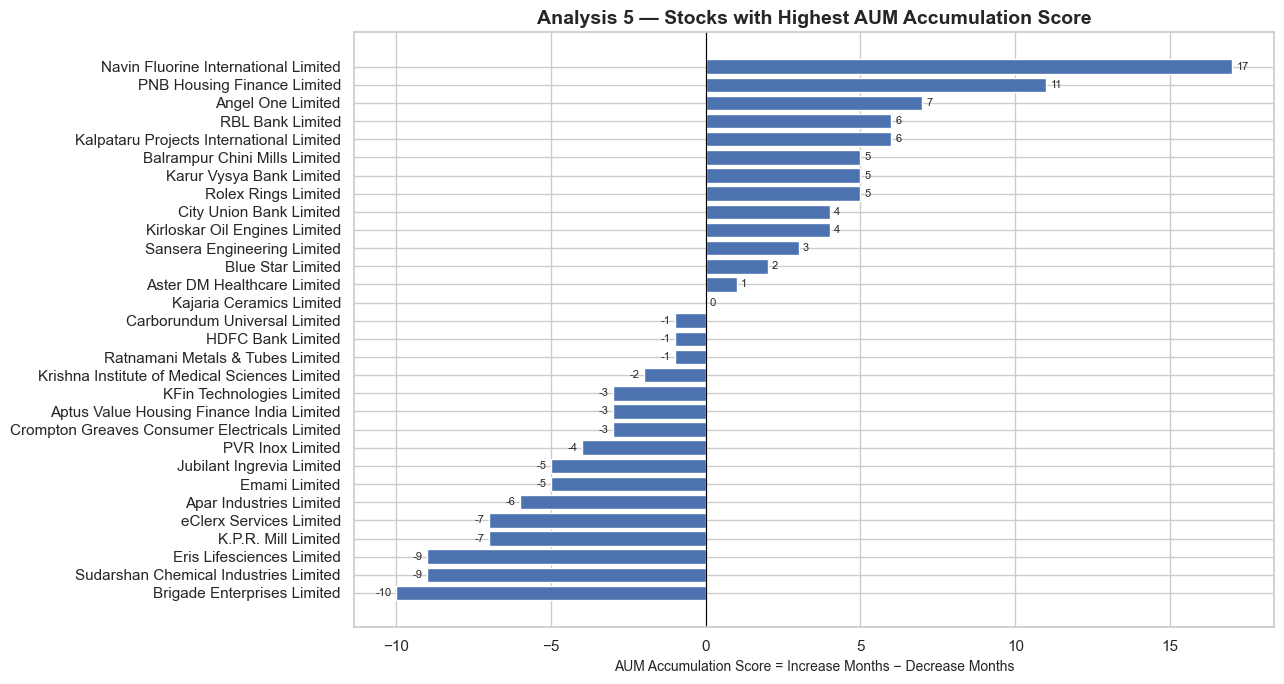

In [102]:
top_accumulation = accumulation_df.head(30).sort_values(
    "AUM_Accumulation_Score",
    ascending=True
)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top_accumulation["Stock"],
    top_accumulation["AUM_Accumulation_Score"]
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f'{v:.0f}' for v in top_accumulation["AUM_Accumulation_Score"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 5 — Stocks with Highest AUM Accumulation Score",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "AUM Accumulation Score = Increase Months − Decrease Months",
    fontsize=10
)

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

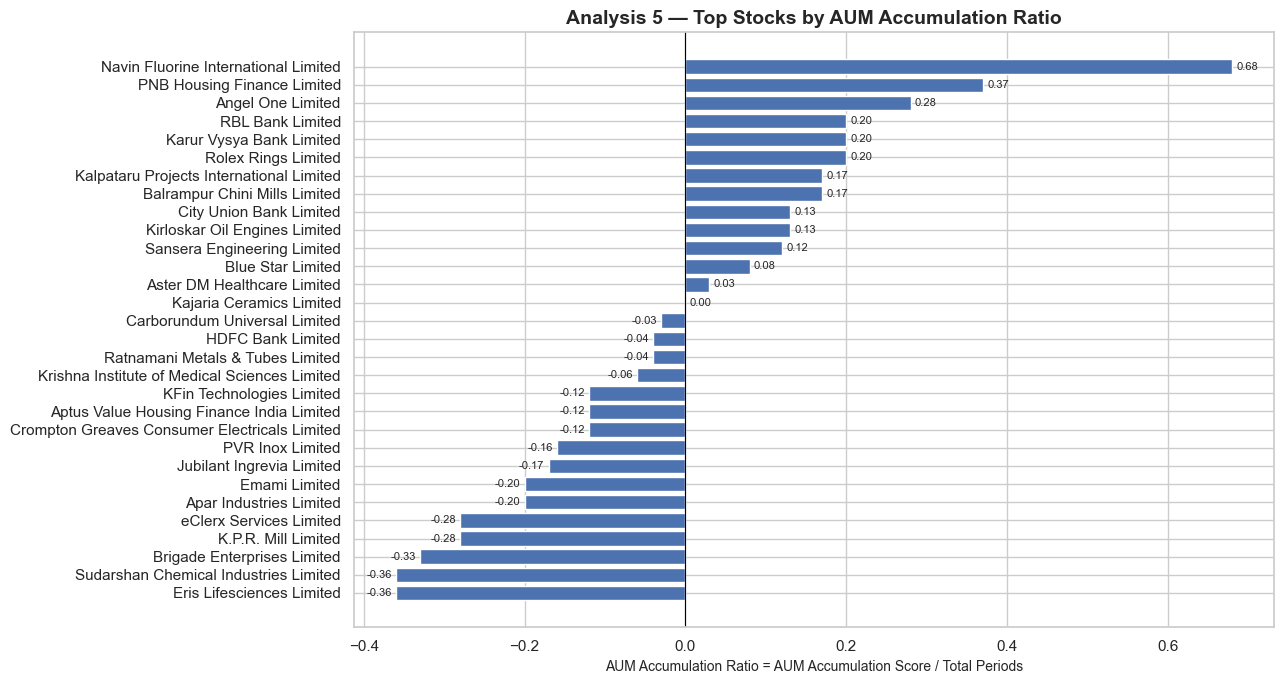

In [103]:
# Graph — Top stocks by AUM Accumulation Ratio

top_ratio = accumulation_df.sort_values(
    ["AUM_Accumulation_Ratio", "Total_Net_AUM_Change_Cr"],
    ascending=False
).head(30)

# For horizontal bar chart, sort ascending
top_ratio_plot = top_ratio.sort_values("AUM_Accumulation_Ratio", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top_ratio_plot["Stock"],
    top_ratio_plot["AUM_Accumulation_Ratio"]
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f'{v:.2f}' for v in top_ratio_plot["AUM_Accumulation_Ratio"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 5 — Top Stocks by AUM Accumulation Ratio",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "AUM Accumulation Ratio = AUM Accumulation Score / Total Periods",
    fontsize=10
)

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

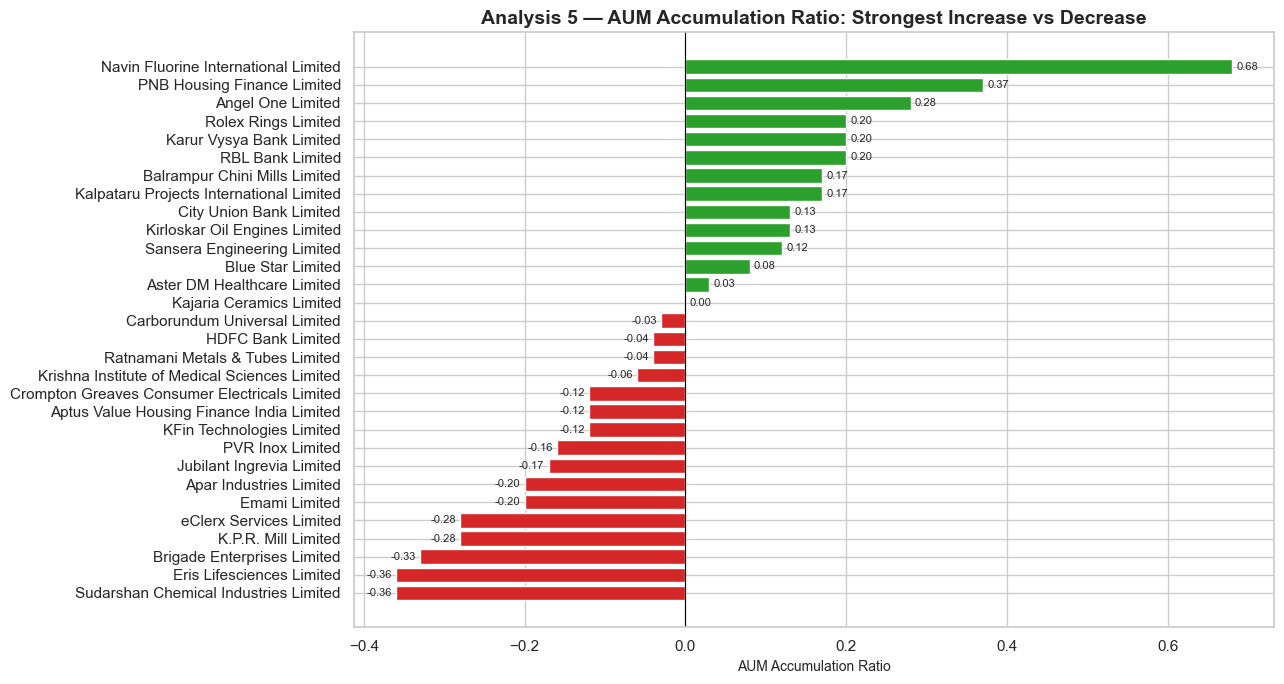

In [104]:
# Graph — Highest and Lowest AUM Accumulation Ratio

top_positive = accumulation_df.nlargest(15, "AUM_Accumulation_Ratio")
top_negative = accumulation_df.nsmallest(15, "AUM_Accumulation_Ratio")

ratio_combined = pd.concat([top_positive, top_negative])
ratio_combined = ratio_combined.drop_duplicates(subset=["Stock"])
ratio_combined = ratio_combined.sort_values("AUM_Accumulation_Ratio", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

colors = [
    "#2ca02c" if v > 0 else "#d62728"
    for v in ratio_combined["AUM_Accumulation_Ratio"]
]

bars = ax.barh(
    ratio_combined["Stock"],
    ratio_combined["AUM_Accumulation_Ratio"],
    color=colors
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f'{v:.2f}' for v in ratio_combined["AUM_Accumulation_Ratio"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 5 — AUM Accumulation Ratio: Strongest Increase vs Decrease",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "AUM Accumulation Ratio",
    fontsize=10
)

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

---
## Analysis 6 — New Entries & Exits
**Question:** Which stocks entered or exited each fund's portfolio during Nov-25 to Apr-26?

#### New Entry = stock was missing/zero in Nov-25 but appears with positive AUM by Apr-26 ####
#### Exit = stock had positive AUM in Nov-25 but is missing/zero by Apr-26 ####

In [105]:
## Analysis 6 — New Entries & Exits
# Question: Which stocks entered or exited each fund's portfolio during Nov-25 to Apr-26?

START_MONTH = "2025-11"
END_MONTH = "2026-04"

entry_exit_data = []

for fund, df in raw_data.items():
    
    df = df.replace("-", np.nan).copy()
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # If same stock appears more than once, combine stock-wise AUM
    df = df.groupby(df.index).sum(numeric_only=True)
    
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        print(f"⚠️ Skipping {fund} — missing start or end month")
        continue
    
    start = df[START_MONTH]
    end = df[END_MONTH]
    
    # Treat NaN as 0 for entry/exit identification
    start_filled = start.fillna(0)
    end_filled = end.fillna(0)
    
    # New Entry: zero/missing at start, positive at end
    new_entries = df[(start_filled <= 0) & (end_filled > 0)].copy()
    
    # Exit: positive at start, zero/missing at end
    exits = df[(start_filled > 0) & (end_filled <= 0)].copy()
    
    for stock in new_entries.index:
        entry_exit_data.append({
            "Fund": fund,
            "Stock": stock,
            "Status": "New Entry",
            "Start AUM (₹ Cr)": round(start_filled.loc[stock], 2),
            "End AUM (₹ Cr)": round(end_filled.loc[stock], 2),
            "AUM Change (₹ Cr)": round(end_filled.loc[stock] - start_filled.loc[stock], 2)
        })
    
    for stock in exits.index:
        entry_exit_data.append({
            "Fund": fund,
            "Stock": stock,
            "Status": "Exit",
            "Start AUM (₹ Cr)": round(start_filled.loc[stock], 2),
            "End AUM (₹ Cr)": round(end_filled.loc[stock], 2),
            "AUM Change (₹ Cr)": round(end_filled.loc[stock] - start_filled.loc[stock], 2)
        })

entry_exit_df = pd.DataFrame(entry_exit_data)
# 🔥 Stocks Newly Entered in Multiple Funds

multi_new_entries = (
    entry_exit_df[entry_exit_df["Status"] == "New Entry"]
    .groupby("Stock")
    .agg(
        Number_of_Funds_Entered=("Fund", "nunique"),
        Funds_Entered=("Fund", lambda x: ", ".join(sorted(x.unique()))),
        Total_New_Entry_AUM_Cr=("End AUM (₹ Cr)", "sum")
    )
    .reset_index()
)

# Keep only stocks entered by more than 1 fund
multi_new_entries = multi_new_entries[
    multi_new_entries["Number_of_Funds_Entered"] >= 2
]

multi_new_entries = multi_new_entries.sort_values(
    ["Number_of_Funds_Entered", "Total_New_Entry_AUM_Cr"],
    ascending=False
)

print("🔥 Stocks Newly Entered in Multiple Funds:")
display(
    multi_new_entries[
        ["Stock", "Number_of_Funds_Entered", "Funds_Entered", "Total_New_Entry_AUM_Cr"]
    ].reset_index(drop=True)
)
print("🚪 Analysis 6 — New Entries & Exits")
display(entry_exit_df.reset_index(drop=True))

🔥 Stocks Newly Entered in Multiple Funds:


,Stock,Number_of_Funds_Entered,Funds_Entered,Total_New_Entry_AUM_Cr
0,Fractal Analytics Limited,2,"Bandhan, SBI",443.61
1,Wakefit Innovations Limited,2,"Bandhan, HDFC",220.06
2,Kotak Mahindra Bank Limited,2,"Bandhan, Franklin",219.82
3,Triveni Turbine Limited,2,"Nippon India, Quant",160.65
4,Sudeep Pharma Limited,2,"AXIS, Quant",151.40
5,Bharat Coking Coal Limited,2,"Bandhan, Nippon India",105.77
6,PTC India Limited,2,"Nippon India, Quant",67.90
7,Safari Industries India Limited,2,"Bandhan, Quant",17.22


🚪 Analysis 6 — New Entries & Exits


,Fund,Stock,Status,Start AUM (₹ Cr),End AUM (₹ Cr),AUM Change (₹ Cr)
0,HSBC,Angel One Limited,New Entry,0.00,98.35,98.35
1,HSBC,BSE Limited,New Entry,0.00,321.29,321.29
2,HSBC,Craftsman Automation Limited,New Entry,0.00,208.18,208.18
3,HSBC,Godfrey Phillips India Limited,New Entry,0.00,49.18,49.18
4,HSBC,Kirloskar Oil Engines Limited,New Entry,0.00,88.52,88.52
...,...,...,...,...,...,...
224,Bandhan,PG Electroplast Limited,Exit,9.09,0.00,-9.09
225,Bandhan,Rishabh Instruments Limited,Exit,3.63,0.00,-3.63
226,Bandhan,Sai Life Sciences Limited,Exit,38.17,0.00,-38.17
227,Bandhan,Spicejet Limited,Exit,50.89,0.00,-50.89


In [106]:
entry_exit_summary = entry_exit_df.groupby(["Fund", "Status"]).agg(
    Stock_Count=("Stock", "count"),
    Total_AUM_Change_Cr=("AUM Change (₹ Cr)", "sum")
).round(2).reset_index()

print("📊 Fund-wise New Entries & Exits Summary")
display(entry_exit_summary)

📊 Fund-wise New Entries & Exits Summary


,Fund,Status,Stock_Count,Total_AUM_Change_Cr
0,AXIS,Exit,14,-2302.14
1,AXIS,New Entry,16,2796.62
2,Bandhan,Exit,15,-276.26
3,Bandhan,New Entry,29,1916.14
4,DSP,Exit,3,-318.08
5,DSP,New Entry,2,424.37
6,Franklin,Exit,18,-1178.41
7,Franklin,New Entry,4,434.90
8,HDFC,Exit,4,-342.19
9,HDFC,New Entry,6,1209.92


In [107]:
stock_entry_exit_summary = entry_exit_df.groupby(["Stock", "Status"]).agg(
    Funds_Count=("Fund", "nunique"),
    Funds=("Fund", lambda x: ", ".join(sorted(x.unique()))),
    Total_AUM_Change_Cr=("AUM Change (₹ Cr)", "sum")
).round(2).reset_index()

stock_entry_exit_summary = stock_entry_exit_summary.sort_values(
    ["Status", "Funds_Count", "Total_AUM_Change_Cr"],
    ascending=[True, False, False]
)

print("📌 Stock-level Entry/Exit Summary Across Funds")
display(stock_entry_exit_summary.reset_index(drop=True))

📌 Stock-level Entry/Exit Summary Across Funds


,Stock,Status,Funds_Count,Funds,Total_AUM_Change_Cr
0,Stanley Lifestyles Limited,Exit,2,"Franklin, Quant",-38.08
1,Indiamart Intermesh Limited,Exit,2,"Bandhan, Nippon India",-78.10
2,JK Tyre & Industries Limited,Exit,2,"Bandhan, HSBC",-110.10
3,KNR Constructions Limited,Exit,2,"Franklin, SBI",-258.48
4,CCL Products (India) Limited,Exit,1,SBI,-3.63
...,...,...,...,...,...
212,Genus Prime Infra Limited,New Entry,1,Nippon India,7.27
213,CSB Bank Limited,New Entry,1,Bandhan,5.07
214,Kalpataru Projects International Limited,New Entry,1,Bandhan,5.07
215,Kalyani Steels Limited,New Entry,1,Quant,3.04


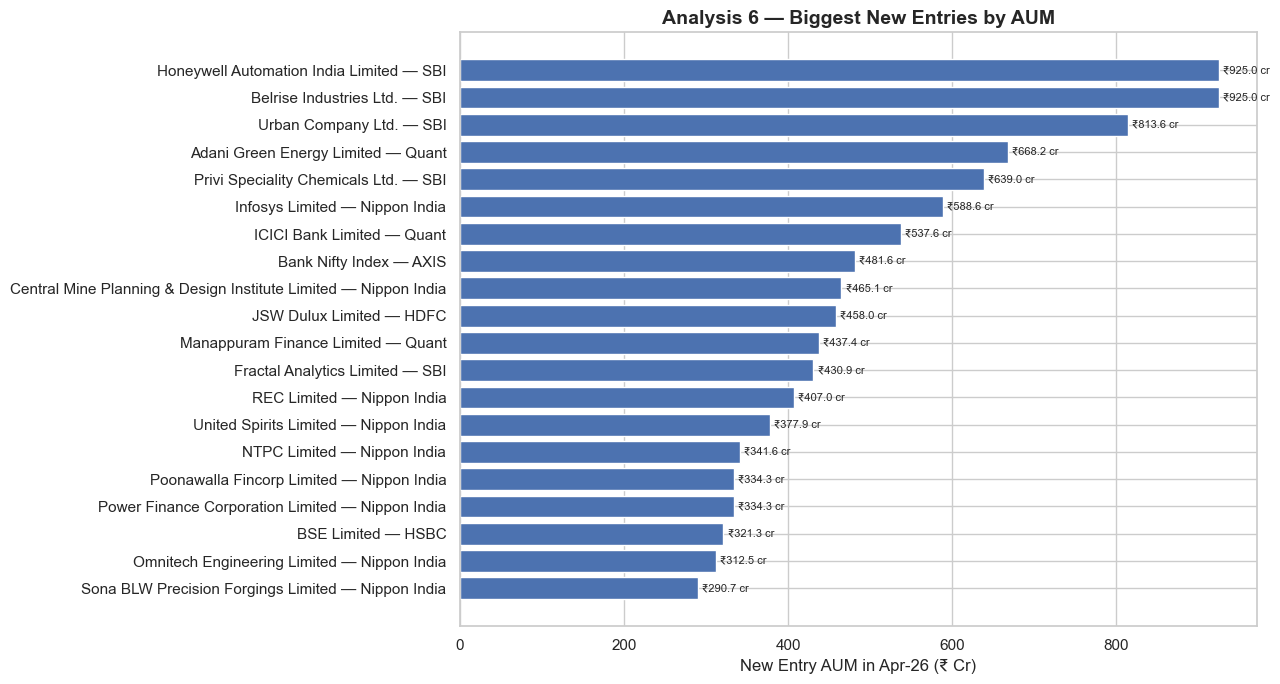

In [108]:
top_new_entries = entry_exit_df[
    entry_exit_df["Status"] == "New Entry"
].sort_values(
    "AUM Change (₹ Cr)",
    ascending=False
).head(20)

top_new_entries_plot = top_new_entries.sort_values("AUM Change (₹ Cr)")

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top_new_entries_plot["Stock"] + " — " + top_new_entries_plot["Fund"],
    top_new_entries_plot["AUM Change (₹ Cr)"]
)

ax.bar_label(
    bars,
    labels=[f"₹{v:,.1f} cr" for v in top_new_entries_plot["AUM Change (₹ Cr)"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 6 — Biggest New Entries by AUM",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("New Entry AUM in Apr-26 (₹ Cr)")

plt.subplots_adjust(left=0.40, right=0.95)
plt.tight_layout()
plt.show()

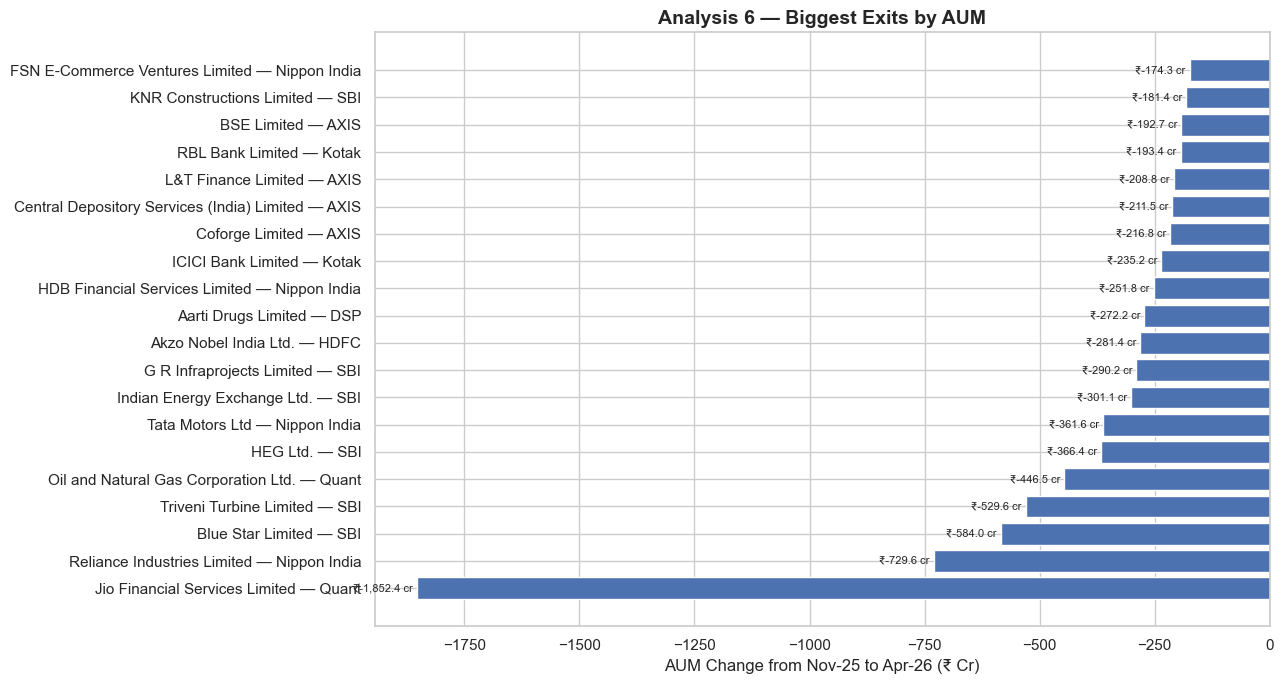

In [109]:
top_exits = entry_exit_df[
    entry_exit_df["Status"] == "Exit"
].sort_values(
    "AUM Change (₹ Cr)",
    ascending=True
).head(20)

top_exits_plot = top_exits.sort_values("AUM Change (₹ Cr)", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top_exits_plot["Stock"] + " — " + top_exits_plot["Fund"],
    top_exits_plot["AUM Change (₹ Cr)"]
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f"₹{v:,.1f} cr" for v in top_exits_plot["AUM Change (₹ Cr)"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 6 — Biggest Exits by AUM",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("AUM Change from Nov-25 to Apr-26 (₹ Cr)")

plt.subplots_adjust(left=0.40, right=0.95)
plt.tight_layout()
plt.show()

In [110]:
# ⚰️ Stocks Exited from Multiple Funds

multi_exits = (
    entry_exit_df[entry_exit_df["Status"] == "Exit"]
    .groupby("Stock")
    .agg(
        Number_of_Funds_Exited=("Fund", "nunique"),
        Funds_Exited=("Fund", lambda x: ", ".join(sorted(x.unique()))),
        Total_Exited_AUM_Cr=("Start AUM (₹ Cr)", "sum")
    )
    .reset_index()
)

# Keep only stocks exited by more than 1 fund
multi_exits = multi_exits[
    multi_exits["Number_of_Funds_Exited"] >= 2
]

multi_exits = multi_exits.sort_values(
    ["Number_of_Funds_Exited", "Total_Exited_AUM_Cr"],
    ascending=False
)

print("⚰️ Stocks Exited from Multiple Funds:")
display(
    multi_exits[
        ["Stock", "Number_of_Funds_Exited", "Funds_Exited", "Total_Exited_AUM_Cr"]
    ].reset_index(drop=True)
)

⚰️ Stocks Exited from Multiple Funds:


,Stock,Number_of_Funds_Exited,Funds_Exited,Total_Exited_AUM_Cr
0,KNR Constructions Limited,2,"Franklin, SBI",258.48
1,JK Tyre & Industries Limited,2,"Bandhan, HSBC",110.10
2,Indiamart Intermesh Limited,2,"Bandhan, Nippon India",78.10
3,Stanley Lifestyles Limited,2,"Franklin, Quant",38.08


In [111]:
print("🔥 Stocks Newly Entered in Multiple Funds:")

display(
    multi_new_entries[
        ["Stock", "Number_of_Funds_Entered"]
    ].reset_index(drop=True)
)

print("⚰️ Stocks Exited from Multiple Funds:")

display(
    multi_exits[
        ["Stock", "Number_of_Funds_Exited"]
    ].reset_index(drop=True)
)

🔥 Stocks Newly Entered in Multiple Funds:


,Stock,Number_of_Funds_Entered
0,Fractal Analytics Limited,2
1,Wakefit Innovations Limited,2
2,Kotak Mahindra Bank Limited,2
3,Triveni Turbine Limited,2
4,Sudeep Pharma Limited,2
5,Bharat Coking Coal Limited,2
6,PTC India Limited,2
7,Safari Industries India Limited,2


⚰️ Stocks Exited from Multiple Funds:


,Stock,Number_of_Funds_Exited
0,KNR Constructions Limited,2
1,JK Tyre & Industries Limited,2
2,Indiamart Intermesh Limited,2
3,Stanley Lifestyles Limited,2


---
## Analysis 7 — Strong Buy / Strong Sell Stocks
**Question:** Which stocks saw large AUM changes (threshold ≥ ±100 cr)?

In [112]:
THRESHOLD = 1

strong_signals = []
for fund, df in raw_data.items():
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        continue
    change = (df[END_MONTH] - df[START_MONTH]).dropna()
    strong = change[change.abs() >= THRESHOLD]
    for stock, val in strong.items():
        strong_signals.append({
            'Fund': fund, 'Stock': stock,
            'Nov-25': df.loc[stock, START_MONTH] if START_MONTH in df.columns else np.nan,
            'Apr-26': df.loc[stock, END_MONTH] if END_MONTH in df.columns else np.nan,
            'Change': round(val, 2),
            'Signal': '🟢 Strong Buy' if val > 0 else '🔴 Strong Sell'
        })

ss_df = pd.DataFrame(strong_signals).sort_values('Change', ascending=False)

print(f'🎯 Strong Buy / Sell Signals (|Change| ≥ {THRESHOLD})')
print('\n🟢 TOP STRONG BUYS:')
display(ss_df[ss_df['Change'] >= THRESHOLD].head(20).reset_index(drop=True))

print('\n🔴 TOP STRONG SELLS:')
display(ss_df[ss_df['Change'] <= -THRESHOLD].sort_values('Change').head(20).reset_index(drop=True))

# Stocks with strong buy signal from multiple funds
print('\n🏆 Stocks with Strong Buy from Multiple Funds:')
multi_strong_buy = ss_df[ss_df['Change'] >= THRESHOLD].groupby('Stock')['Fund'].count().sort_values(ascending=False)
display(multi_strong_buy[multi_strong_buy > 1].head(20).reset_index().rename(columns={'Fund': 'Funds with Strong Buy'}))

🎯 Strong Buy / Sell Signals (|Change| ≥ 1)

🟢 TOP STRONG BUYS:


,Fund,Stock,Nov-25,Apr-26,Change,Signal
0,SBI,ZF Commercial Vehicle Control Systems India Limited,340.956518,1029.055,688.10,🟢 Strong Buy
1,Quant,HFCL Limited,561.162,1044.8656,483.70,🟢 Strong Buy
2,Quant,Adani Power Limited,890.015,1330.3812,440.37,🟢 Strong Buy
3,SBI,Ather Energy Limited,1443.624406,1879.79,436.17,🟢 Strong Buy
4,Nippon India,Bharat Heavy Electricals Limited,807.1375,1213.6391,406.50,🟢 Strong Buy
5,Nippon India,MTAR Technologies Limited,219.5414,603.1859,383.64,🟢 Strong Buy
6,Nippon India,TD Power Systems Limited,749.0236,1119.1642,370.14,🟢 Strong Buy
7,Bandhan,REC Limited,517.954725,884.568071,366.61,🟢 Strong Buy
8,HDFC,Tega Industries Limited,41.822,385.4968,343.67,🟢 Strong Buy
9,SBI,Anand Rathi Wealth Limited,431.636443,757.86,326.22,🟢 Strong Buy



🔴 TOP STRONG SELLS:


,Fund,Stock,Nov-25,Apr-26,Change,Signal
0,HDFC,Firstsource Solutions Limited,1912.406,1209.9256,-702.48,🔴 Strong Sell
1,HDFC,eClerx Services Limited,1497.988,896.948,-601.04,🔴 Strong Sell
2,Nippon India,ITC Limited,677.9955,159.8806,-518.11,🔴 Strong Sell
3,Nippon India,Multi Commodity Exchange of India Limited,1756.3312,1279.0448,-477.29,🔴 Strong Sell
4,Quant,Aegis Logistics Limited,1007.678,558.8816,-448.80,🔴 Strong Sell
5,SBI,Lemon Tree Hotels Limited,551.333944,152.315,-399.02,🔴 Strong Sell
6,SBI,Indiamart Intermesh Limited,330.074927,11.145,-318.93,🔴 Strong Sell
7,Nippon India,Asian Paints Limited,626.3387,334.2958,-292.04,🔴 Strong Sell
8,HSBC,Multi Commodity Exchange of India Limited,528.251378,237.68603,-290.57,🔴 Strong Sell
9,Quant,Minda Corporation Limited,425.397,142.7578,-282.64,🔴 Strong Sell



🏆 Stocks with Strong Buy from Multiple Funds:


,Stock,Funds with Strong Buy
0,Aster DM Healthcare Limited,6
1,Apar Industries Limited,6
2,Kalpataru Projects International Limited,6
3,Ratnamani Metals & Tubes Limited,5
4,PNB Housing Finance Limited,5
5,RBL Bank Limited,5
6,Jubilant Ingrevia Limited,5
7,Metropolis Healthcare Limited,4
8,Sansera Engineering Limited,4
9,Rolex Rings Limited,4


---
## Analysis 8 — Fund Overlap Matrix
**Question:** Which funds have similar portfolios? Which provide real diversification?

📊 Fund Overlap Matrix — Common Stock Count (Apr-26)
  (Diagonal = total holdings of the fund)


,HSBC,Nippon India,HDFC,SBI,Quant,AXIS,Kotak,Franklin,DSP,Bandhan
HSBC,107,40,13,15,9,26,16,25,17,26
Nippon India,40,245,31,28,24,43,22,40,26,66
HDFC,13,31,84,7,3,9,12,10,14,18
SBI,15,28,7,64,7,14,15,14,13,14
Quant,9,24,3,7,100,5,4,6,10,26
AXIS,26,43,9,14,5,77,17,19,14,27
Kotak,16,22,12,15,4,17,75,14,16,20
Franklin,25,40,10,14,6,19,14,85,12,35
DSP,17,26,14,13,10,14,16,12,81,21
Bandhan,26,66,18,14,26,27,20,35,21,245


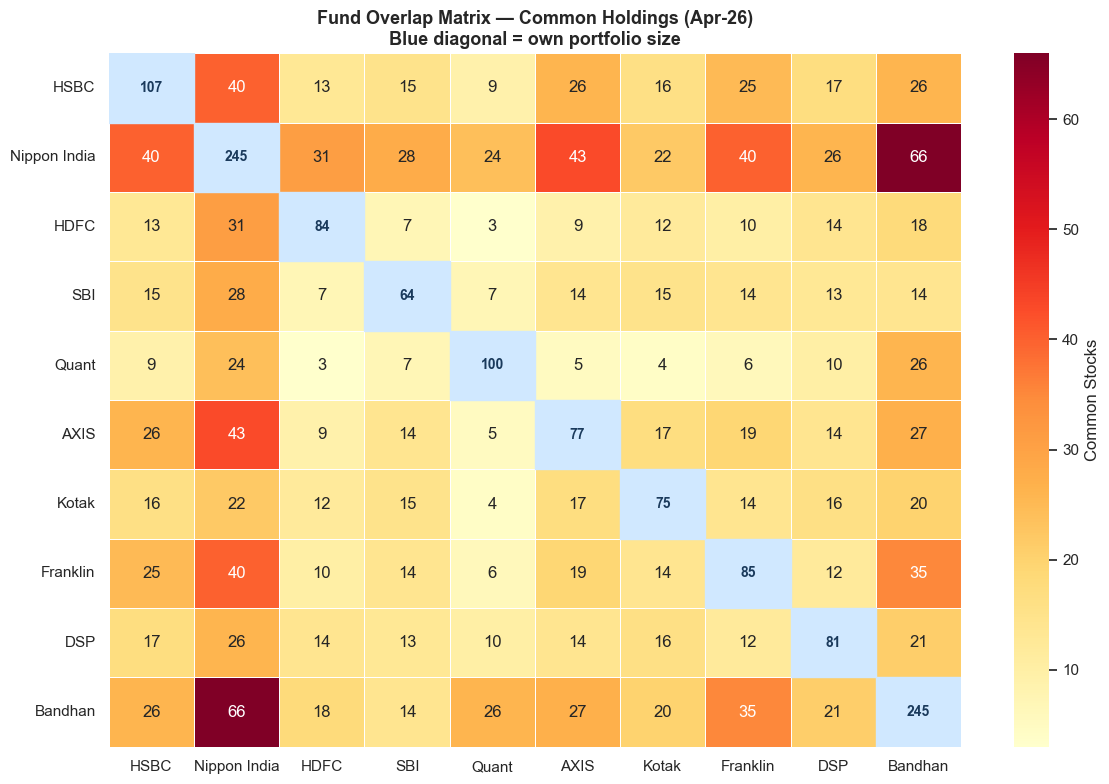


📐 Jaccard Similarity Matrix (% overlap — higher = more similar)


,HSBC,Nippon India,HDFC,SBI,Quant,AXIS,Kotak,Franklin,DSP,Bandhan
HSBC,100.0,12.8,7.3,9.6,4.5,16.5,9.6,15.0,9.9,8.0
Nippon India,12.8,100.0,10.4,10.0,7.5,15.4,7.4,13.8,8.7,15.6
HDFC,7.3,10.4,100.0,5.0,1.7,5.9,8.2,6.3,9.3,5.8
SBI,9.6,10.0,5.0,100.0,4.5,11.0,12.1,10.4,9.8,4.7
Quant,4.5,7.5,1.7,4.5,100.0,2.9,2.3,3.4,5.8,8.2
AXIS,16.5,15.4,5.9,11.0,2.9,100.0,12.6,13.3,9.7,9.2
Kotak,9.6,7.4,8.2,12.1,2.3,12.6,100.0,9.6,11.4,6.7
Franklin,15.0,13.8,6.3,10.4,3.4,13.3,9.6,100.0,7.8,11.9
DSP,9.9,8.7,9.3,9.8,5.8,9.7,11.4,7.8,100.0,6.9
Bandhan,8.0,15.6,5.8,4.7,8.2,9.2,6.7,11.9,6.9,100.0


In [113]:
# Overlap = number of common stocks held in Apr-26
holdings_apr = {}
for fund, df in raw_data.items():
    if END_MONTH in df.columns:
        held = set(df[END_MONTH].dropna()[df[END_MONTH].dropna() > 0].index)
        holdings_apr[fund] = held

fund_list = list(holdings_apr.keys())
n = len(fund_list)

# Common stock count matrix
overlap_matrix = pd.DataFrame(0, index=fund_list, columns=fund_list)
for f1, f2 in combinations(fund_list, 2):
    common = len(holdings_apr[f1] & holdings_apr[f2])
    overlap_matrix.loc[f1, f2] = common
    overlap_matrix.loc[f2, f1] = common
for f in fund_list:
    overlap_matrix.loc[f, f] = len(holdings_apr[f])

print('📊 Fund Overlap Matrix — Common Stock Count (Apr-26)')
print('  (Diagonal = total holdings of the fund)')
display(overlap_matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.eye(n, dtype=bool)
sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='YlOrRd', mask=mask,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Common Stocks'})
# Diagonal with different color
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#d0e8ff', zorder=3))
    ax.text(i + 0.5, i + 0.5, str(overlap_matrix.iloc[i, i]),
            ha='center', va='center', fontsize=10, fontweight='bold', color='#1a3a5c', zorder=4)
ax.set_title('Fund Overlap Matrix — Common Holdings (Apr-26)\nBlue diagonal = own portfolio size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Also: % overlap (Jaccard similarity)
jaccard_matrix = pd.DataFrame(0.0, index=fund_list, columns=fund_list)

for f1, f2 in combinations(fund_list, 2):
    union = len(holdings_apr[f1] | holdings_apr[f2])
    inter = len(holdings_apr[f1] & holdings_apr[f2])
    jaccard = inter / union if union > 0 else 0
    
    jaccard_matrix.loc[f1, f2] = round(jaccard * 100, 1)
    jaccard_matrix.loc[f2, f1] = round(jaccard * 100, 1)

for f in fund_list:
    jaccard_matrix.loc[f, f] = 100.0



# Column sum
column_sum = jaccard_matrix.sum(axis=0)
jaccard_matrix.loc["Column Sum"] = column_sum

print('\n📐 Jaccard Similarity Matrix (% overlap — higher = more similar)')
display(jaccard_matrix)

---
## Analysis 9 — Stock Popularity Ranking
**Question:** Which stocks are most popular among small-cap fund managers across all months?

🌟 Stock Popularity Ranking (Average # of Funds Holding — Nov-25 to Apr-26)


,Stock,Avg Funds Holding,Max Funds Holding
Rank,,,
1,Aster DM Healthcare Limited,7.0,7
2,Krishna Institute of Medical Sciences Limited,6.3,7
3,Kalpataru Projects International Limited,6.3,7
4,City Union Bank Limited,6.0,6
5,Kirloskar Oil Engines Limited,5.8,6
6,Apar Industries Limited,5.8,6
7,PVR Inox Limited,5.7,6
8,Kajaria Ceramics Limited,5.7,6
9,PNB Housing Finance Limited,5.5,6


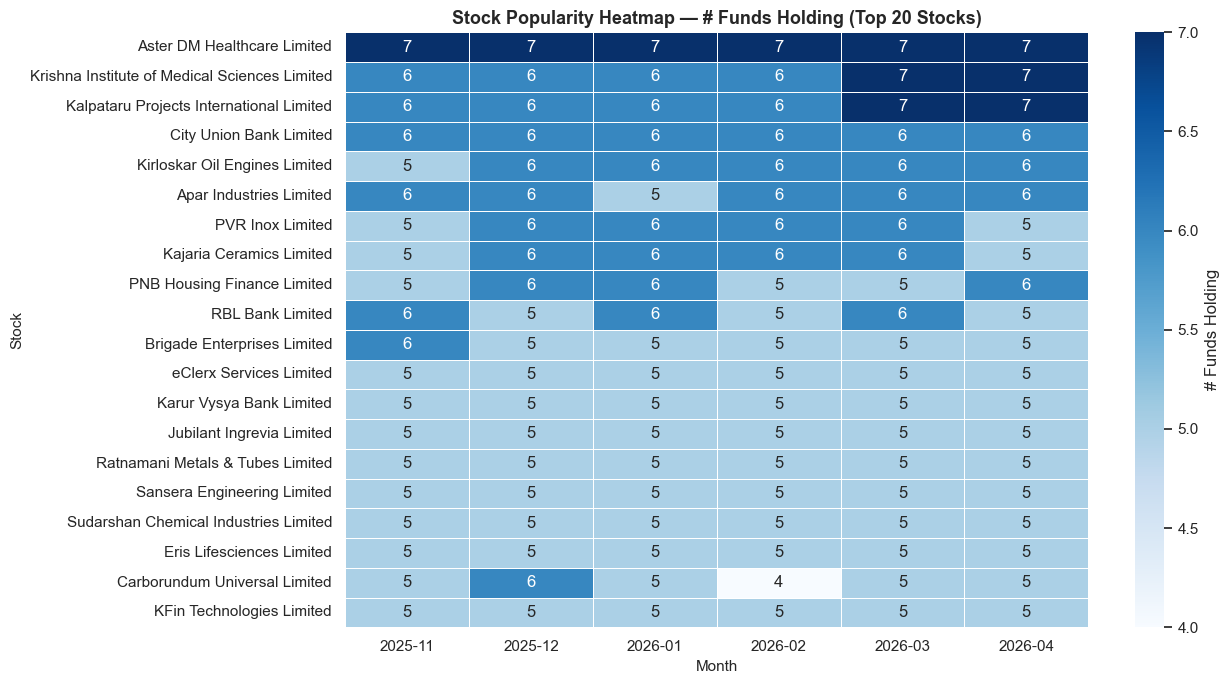

In [114]:
# Build monthly popularity: for each month, count how many funds hold each stock
popularity_records = []
for month in MONTHS_ORDER:
    month_counts = {}
    for fund, df in raw_data.items():
        if month in df.columns:
            held = df[month].dropna()
            held = held[held > 0]
            for stock in held.index:
                month_counts[stock] = month_counts.get(stock, 0) + 1
    for stock, cnt in month_counts.items():
        popularity_records.append({'Month': month, 'Stock': stock, 'Funds Holding': cnt})

pop_df = pd.DataFrame(popularity_records)

# Average popularity across all months
avg_pop = pop_df.groupby('Stock')['Funds Holding'].mean().sort_values(ascending=False)
max_pop = pop_df.groupby('Stock')['Funds Holding'].max()

pop_rank = pd.DataFrame({
    'Stock': avg_pop.index,
    'Avg Funds Holding': avg_pop.values.round(1),
    'Max Funds Holding': max_pop.reindex(avg_pop.index).values
}).reset_index(drop=True)
pop_rank.index = range(1, len(pop_rank)+1)
pop_rank.index.name = 'Rank'

print('🌟 Stock Popularity Ranking (Average # of Funds Holding — Nov-25 to Apr-26)')
display(pop_rank.head(30))

# Monthly popularity heatmap for top 20 stocks
top20_stocks = avg_pop.head(20).index.tolist()
pop_pivot = pop_df[pop_df['Stock'].isin(top20_stocks)].pivot_table(
    index='Stock', columns='Month', values='Funds Holding', fill_value=0)
pop_pivot = pop_pivot.reindex(columns=MONTHS_ORDER, fill_value=0)
pop_pivot = pop_pivot.loc[top20_stocks]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pop_pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.4,
            ax=ax, cbar_kws={'label': '# Funds Holding'})
ax.set_title('Stock Popularity Heatmap — # Funds Holding (Top 20 Stocks)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Stock', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 10 — Concentration Analysis
**Question:** Which funds are more concentrated or more diversified?

🔍 Concentration Analysis — Apr-26 Snapshot
   HHI: Higher = More Concentrated | Lower = More Diversified


,Fund,Month,No. of Stocks,Top-10 AUM (cr),Total AUM,HHI (Concentration)
0,Quant,2026-04,100,11426.70,27859.04,295.8
1,SBI,2026-04,64,10387.14,32019.59,224.1
2,Nippon India,2026-04,245,10384.97,70274.79,67.6
3,HDFC,2026-04,84,10183.22,34522.96,177.7
4,AXIS,2026-04,77,5431.75,19589.87,165.4
5,DSP,2026-04,81,5251.83,16412.64,195.3
6,Kotak,2026-04,81,4909.71,17329.40,172.5
7,Bandhan,2026-04,245,4797.96,21926.64,103.0
8,HSBC,2026-04,107,3332.52,16138.06,127.2
9,Franklin,2026-04,85,2998.58,13105.11,144.9


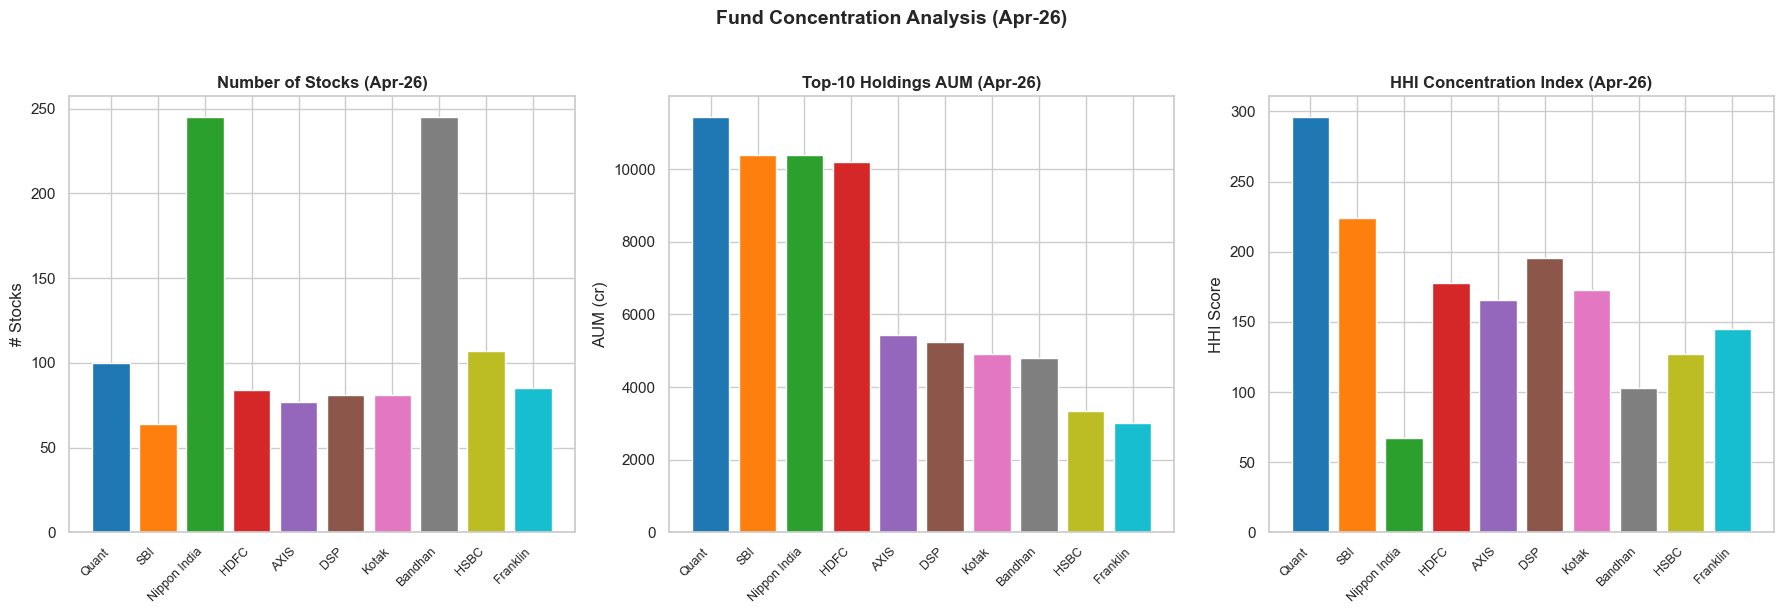

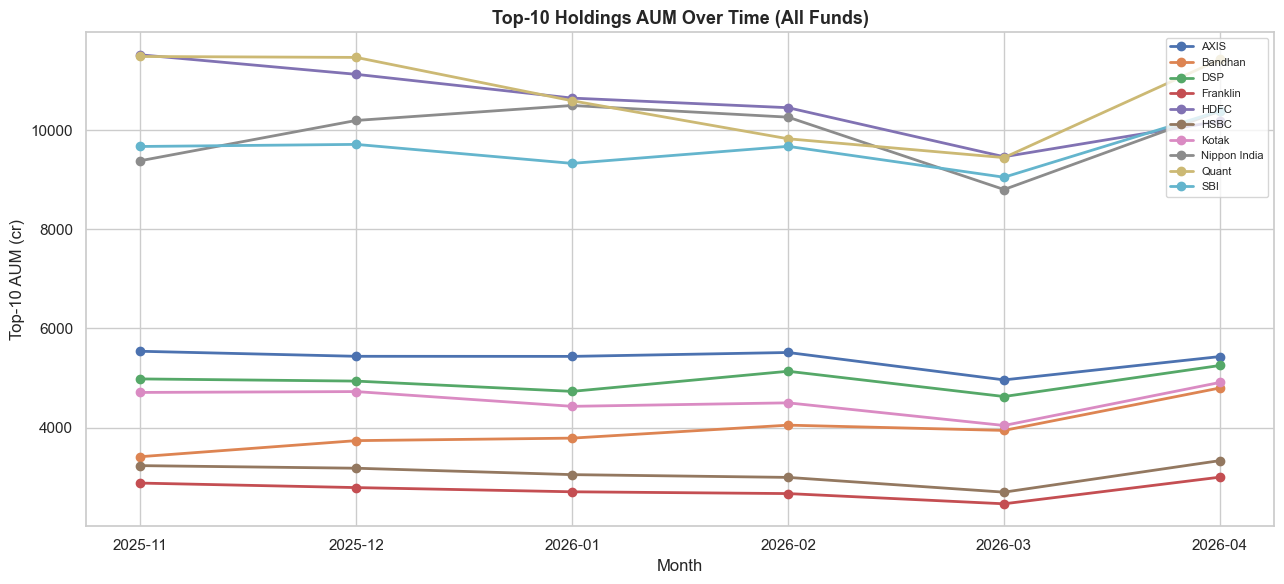

In [115]:
conc_data = []

for fund in FUNDS:
    df = raw_data[fund]
    
    for month in MONTHS_ORDER:
        if month not in df.columns:
            continue
        col = df[month].dropna()
        col = col[col > 0]
        
        if col.empty:
            continue
        
        total_alloc = col.sum()
        top10_alloc = col.nlargest(10).sum()
        n_stocks = len(col)
    
        
        # HHI — Herfindahl-Hirschman Index (concentration)
        weights = col / total_alloc
        hhi = (weights ** 2).sum() * 10000  # scale to 0-10000
        
        conc_data.append({
            'Fund': fund, 'Month': month,
            'No. of Stocks': n_stocks,
            'Top-10 AUM (cr)': round(top10_alloc, 2),
            'Total AUM': round(total_alloc, 2),
            'HHI (Concentration)': round(hhi, 1)
        })

conc_df = pd.DataFrame(conc_data)

# Apr-26 snapshot
conc_apr = conc_df[conc_df['Month'] == END_MONTH].sort_values('Top-10 AUM (cr)', ascending=False).reset_index(drop=True)
print('🔍 Concentration Analysis — Apr-26 Snapshot')
print('   HHI: Higher = More Concentrated | Lower = More Diversified')
display(conc_apr)

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: No. of Stocks
axes[0].bar(conc_apr['Fund'], conc_apr['No. of Stocks'], color=sns.color_palette('tab10', len(conc_apr)))
axes[0].set_title('Number of Stocks (Apr-26)', fontweight='bold')
axes[0].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('# Stocks')

# Chart 2: Top-10 AUM (cr)
axes[1].bar(conc_apr['Fund'], conc_apr['Top-10 AUM (cr)'], color=sns.color_palette('tab10', len(conc_apr)))
axes[1].set_title('Top-10 Holdings AUM (Apr-26)', fontweight='bold')
axes[1].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('AUM (cr)')

# Chart 3: HHI
axes[2].bar(conc_apr['Fund'], conc_apr['HHI (Concentration)'], color=sns.color_palette('tab10', len(conc_apr)))
axes[2].set_title('HHI Concentration Index (Apr-26)', fontweight='bold')
axes[2].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('HHI Score')

plt.suptitle('Fund Concentration Analysis (Apr-26)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Monthly trend: Top-10 Allocation over time
conc_pivot = conc_df.pivot(index='Fund', columns='Month', values='Top-10 AUM (cr)')
conc_pivot = conc_pivot.reindex(columns=MONTHS_ORDER)

fig, ax = plt.subplots(figsize=(13, 6))
for fund in conc_pivot.index:
    ax.plot(MONTHS_ORDER, conc_pivot.loc[fund], marker='o', label=fund, linewidth=2)
ax.set_title('Top-10 Holdings AUM Over Time (All Funds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Top-10 AUM (cr)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 📋 Summary Dashboard — Key Insights

In [116]:
import requests
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta

funds = [
    "Nippon India Small Cap Fund",
    "HDFC Small Cap Fund",
    "SBI Small Cap Fund",
    "Quant Small Cap Fund",
    "Axis Small Cap Fund",
    "Bandhan Small Cap Fund",
    "DSP Small Cap Fund",
    "Kotak Small Cap Fund",
    "HSBC Small Cap Fund",
    "Franklin India Small Cap Fund"
]

BASE_URL = "https://api.mfapi.in"


def search_scheme(fund_name):
    """
    Search scheme code from MFAPI.
    Prefer Direct Growth plan if available.
    """
    url = f"{BASE_URL}/mf/search"
    params = {"q": fund_name}
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    schemes = response.json()
    
    # Prefer Direct Growth
    direct_growth = [
        s for s in schemes
        if "direct" in s["schemeName"].lower()
        and "growth" in s["schemeName"].lower()
        and "idcw" not in s["schemeName"].lower()
        and "dividend" not in s["schemeName"].lower()
    ]
    
    if direct_growth:
        return direct_growth[0]
    
    # Fallback: Regular Growth
    growth = [
        s for s in schemes
        if "growth" in s["schemeName"].lower()
        and "idcw" not in s["schemeName"].lower()
        and "dividend" not in s["schemeName"].lower()
    ]
    
    if growth:
        return growth[0]
    
    return schemes[0] if schemes else None


def get_nav_history(scheme_code):
    """
    Get complete NAV history for a scheme code.
    """
    url = f"{BASE_URL}/mf/{scheme_code}"
    response = requests.get(url)
    response.raise_for_status()
    
    data = response.json()
    
    df = pd.DataFrame(data["data"])
    df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
    df["nav"] = pd.to_numeric(df["nav"], errors="coerce")
    
    df = df.dropna(subset=["nav"])
    df = df.sort_values("date")
    
    return df, data["meta"]


def calculate_6m_return(df):
    """
    Calculate 6-month return using nearest available NAV dates.
    """
    latest_date = df["date"].max()
    target_date = latest_date - relativedelta(months=6)
    
    latest_row = df[df["date"] == latest_date].iloc[-1]
    
    # nearest NAV date on or before target date
    past_df = df[df["date"] <= target_date]
    
    if past_df.empty:
        return None
    
    past_row = past_df.iloc[-1]
    
    latest_nav = latest_row["nav"]
    past_nav = past_row["nav"]
    
    return_6m = ((latest_nav / past_nav) - 1) * 100
    
    return {
        "Latest Date": latest_row["date"].date(),
        "Latest NAV": latest_nav,
        "6M Back Date": past_row["date"].date(),
        "6M Back NAV": past_nav,
        "6M Return (%)": round(return_6m, 2)
    }


results = []

for fund in funds:
    try:
        scheme = search_scheme(fund)
        
        if scheme is None:
            results.append({
                "Fund": fund,
                "Scheme Code": None,
                "Matched Scheme": "Not found",
                "6M Return (%)": None
            })
            continue
        
        scheme_code = scheme["schemeCode"]
        matched_scheme = scheme["schemeName"]
        
        df, meta = get_nav_history(scheme_code)
        ret = calculate_6m_return(df)
        
        if ret is None:
            results.append({
                "Fund": fund,
                "Scheme Code": scheme_code,
                "Matched Scheme": matched_scheme,
                "6M Return (%)": None
            })
        else:
            results.append({
                "Fund": fund,
                "Scheme Code": scheme_code,
                "Matched Scheme": matched_scheme,
                "Latest Date": ret["Latest Date"],
                "Latest NAV": ret["Latest NAV"],
                "6M Back Date": ret["6M Back Date"],
                "6M Back NAV": ret["6M Back NAV"],
                "6M Return (%)": ret["6M Return (%)"]
            })
    
    except Exception as e:
        results.append({
            "Fund": fund,
            "Scheme Code": None,
            "Matched Scheme": "Error",
            "6M Return (%)": None,
            "Error": str(e)
        })


final_df = pd.DataFrame(results)

print(final_df)

# Optional: save output
final_df.to_csv("small_cap_fund_6m_returns_mfapi.csv", index=False)

                            Fund  Scheme Code  \
0    Nippon India Small Cap Fund       118777   
1            HDFC Small Cap Fund       130503   
2             SBI Small Cap Fund       125497   
3           Quant Small Cap Fund       120828   
4            Axis Small Cap Fund       125354   
5         Bandhan Small Cap Fund       147946   
6             DSP Small Cap Fund       119212   
7           Kotak Small Cap Fund       120164   
8            HSBC Small Cap Fund       120069   
9  Franklin India Small Cap Fund       118525   

                                                         Matched Scheme  \
0  Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option   
1                     HDFC Small Cap Fund - Growth Option - Direct Plan   
2                             SBI Small Cap Fund - Direct Plan - Growth   
3                    quant Small Cap Fund - Growth Option - Direct Plan   
4                            Axis Small Cap Fund - Direct Plan - Growth   
5         